In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *


color_list = ['#0072b2', '#e69f00', '#56b4e9', '#009e73',
              '#000000', '#f0e442', '#d55e00', '#cc79a7']



In [2]:
def loghisto(linhisto, nbins = 0):
    data = linhisto
    
    last_non_zero = np.nonzero(data)[0]
    nmax = last_non_zero[-1]
    if nbins == 0:
        nbins = freedman_diaconis_log_bins(data[:nmax])
    
    bins, histo = new_logbins(data[:nmax], nbins) #Transforme les bins lin en bins log
    bin_center = (bins[1:] + bins[:-1])/2
    
    mask = histo != 0
    f_histo = histo[mask]
    f_bin_center = bin_center[mask]
    
    return f_histo, f_bin_center

def count_lines_gz_safe(filename, csize = 1000):
    count = 0
    chunk_size = csize 
    try:
        with gzip.open(filename, 'rb') as f:
            leftover = b''
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                lines = (leftover + chunk).split(b'\n')
                leftover = lines.pop()  # dernière ligne peut être tronquée
                count += len(lines)
            if leftover:
                count += 1  # compte la dernière ligne même si tronquée
    except EOFError:
        # fichier tronqué, on arrête là et on retourne le compte
        pass
    return count

def process_parallel_load(foldernb, path = "/data1/DATA_Duplat/Brut/Memory_effects/Me", nb = [1,2,3,4,5,6,7,8,9], chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    histo_s = np.zeros(len(logbins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    for i in nb:
        file = "{}{}n{}/random_random.gz".format(path, foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
                histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
                
                nblines += len(chunk)
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s= int(float(line.strip().split()[cols[0]]))

                    id = np.searchsorted(logbins_s, s, side='right') -1
                    histo_s[id] += 1
                    
                    id = np.searchsorted(logbins_a, 1/s, side='left') - 1
                    histo_a[id] += 1
                    
                    if i >= limdata:
                        break
        
            
    # log_histo, log_bins = loghisto(histo_s)
    norm_histo_s = histo_s/((np.diff(logbins_s)) * np.sum(histo_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    return logbins_s, norm_histo_s, logbins_a, norm_histo_a
    # return log_bins, log_histo, logbins_a, norm_histo_a

def floor_sig(x, n=1): #Pour récupére le floor de la valeur
    p = int(np.floor(np.log10(abs(x))))
    fact = 10 ** (p - n + 1)
    return int(np.floor(x / fact) * fact)

def count_lines(Tfolder_nb, nbfolder):
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        min = 1e10
        for i in range(1,nbfolder+1):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = count_lines_gz_safe(file)
            if nbl < min:
                min = nbl
        print(min)
        
def full_analysis(Tfolder_nb, path = "/data1/DATA_Duplat/Brut/Memory_effects/Me", nbins = 50, cols = [12], nbfolder = [1,2,3,4,5,6,7,8,9]): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for j, nb in enumerate(Tfolder_nb):
        project =  "{}{}".format(path, nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in nbfolder:
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        print(min)
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, path, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a

def full_analysis_bis(Tfolder_nb, nbfolder = 6, nbins = 50, cols = [12], L = 64):#To sum different realisation in the different projects
    Tnbline = [None]*nbfolder
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for n in range(1, (nbfolder+1)):
        min = 1e10
        for i, nb in enumerate(Tfolder_nb):
            file =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(nb, n)
            nbl = count_lines_gz_safe(file)
            if nbl < min:
                min = nbl
        Tnbline[n-1] = floor_sig(min,2)
        
    Tno = np.arange(1,(nbfolder +1))
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load_bis)(Tfolder_nb, no, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (no, nbline) in zip(Tno, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a
    
def process_parallel_load_bis(Tfoldernb, number_folder, chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    histo_s = np.zeros(len(logbins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    
    for i in Tfoldernb:
        nblines = 0
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(i,number_folder)
        for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
            histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
            histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
            
            nblines += len(chunk)
        
            if nblines >= limdata:
                break
    norm_histo_s = histo_s/((np.diff(logbins_s)) * np.sum(histo_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    return logbins_s, norm_histo_s, logbins_a, norm_histo_a    
    
def gamma_th():

    fnb = np.arange(1,15)
    folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
    """ folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
    Tvar = [read_parameters(folder)[2] for folder in folderpath]

    results = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)
    Thisto_s, Tbins_s, _, _, _ = zip(*results)

    Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
    Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
    _, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)
    
    gamma = (-Ttau_s) - (-Ttau_s[0]) - 1
    
    return Tvar, gamma, -Ttau_s
    
def plotfct_Ps_gamma(Tbin_s, Thisto_s, Tn_try, Tnu, Tstart, Tstop, color, Tlabel):
    
    Tnu_th, Tgamma_th = gamma_th()
    Ttau = [None]*len(Tn_try)
    with plt.style.context(spstyle.get_style('nature-reviews')):
        plt.rcParams['font.family'] = 'Arial' 
        fig, (ax, ax2) = plt.subplots(1,2,figsize = (12.8,4.8))

        for j, n in enumerate(Tn_try):
                
            start = np.where(Tbin_s[j] >= Tstart[j])[0][0]
            stop_j = np.where(Tbin_s[j] <= Tstop[j])[0][-1]
            popt, _ = curve_fit(log_exppowlaw, Tbin_s[j][start:stop_j], np.log(Thisto_s[j][start:stop_j]), p0 = [0.5, 1.2, 10], maxfev = 1000)
            tau = popt[1]
            Ttau[j] = -tau
            yfit = np.exp(log_exppowlaw(Tbin_s[j][start:], *popt))

            ax.plot(Tbin_s[j], Thisto_s[j], c = color[j], label = f"{Tlabel[j]}, "+r"$\tau = $" + f"{np.round(tau, 2)}")
            ax.plot(Tbin_s[j][start:], yfit, ls = '--', c ='k', lw =1)
            
        ax2.scatter(Tnu_th, -Tgamma_th, c = color_list[0])
        ax2.scatter(Tnu, 2 - (-np.array(Ttau)), c = color)
        ax2.set_xlabel(r"$\nu$")
        ax2.set_ylabel(r"$\gamma$")
                
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel(r'$s_m$')
        ax.set_ylabel(r'$P(s_m)$')
        ax.legend(loc = "upper right")
    
        plt.show()
    
    
    
    
def gumbel_pdf(x, mu, beta, A=1.0):
    """
    Gumbel probability density function (right-skewed form)
    P(x) = (A / beta) * exp(-(z + exp(-z)))
    where z = (x - mu) / beta
    """
    z = (x - mu) / beta
    return (A / beta) * np.exp(-z - np.exp(-z))

def lognormal_pdf(x, mu, sigma, A):
    return (A / (x * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(x) - mu)**2 / (2*sigma**2))


def double_cutoff_powerlaw(x, alpha, x_min, x_max, A=1.0):
    """
    P(x) = A * exp(-x_min/x) * x^(-alpha) * exp(-x/x_max)
    Gives exponential behavior at both small and large x.
    """
    return A * np.exp(-x_min/x) * x**(-alpha) * np.exp(-x/x_max)

def log_double_cutoff_powerlaw(x, alpha, x_min, x_max, A=1.0):

    return np.log(A) -x_min/x -alpha*np.log(x) -x/x_max


def exppowlaw(x, a, b, c):
    return a * x**(-b) * np.exp(-x/c)

def log_exppowlaw(x, a, b, c):
    return np.log(a)-b*np.log(x)-x/c


#   Snapshot test

In [94]:
folder = '/data1/DATA_Duplat/Brut/Memory_effects/Me6n11'
params = read_parameters(folder)
L1 = params[0]
L2 = params[1
            ]
small_data = np.loadtxt('{}/random_small.txt'.format(folder), usecols = [0,5])

mask = small_data[:,1] == 65536
small_data_not_found = small_data[mask]
small_data_found = small_data[~mask]

large_data = np.loadtxt('{}/random_large.txt'.format(folder), usecols = [0,5])

mask = large_data[:,1] == 65536
large_data_not_found = large_data[mask]
large_data_found = large_data[~mask]


KeyboardInterrupt: 

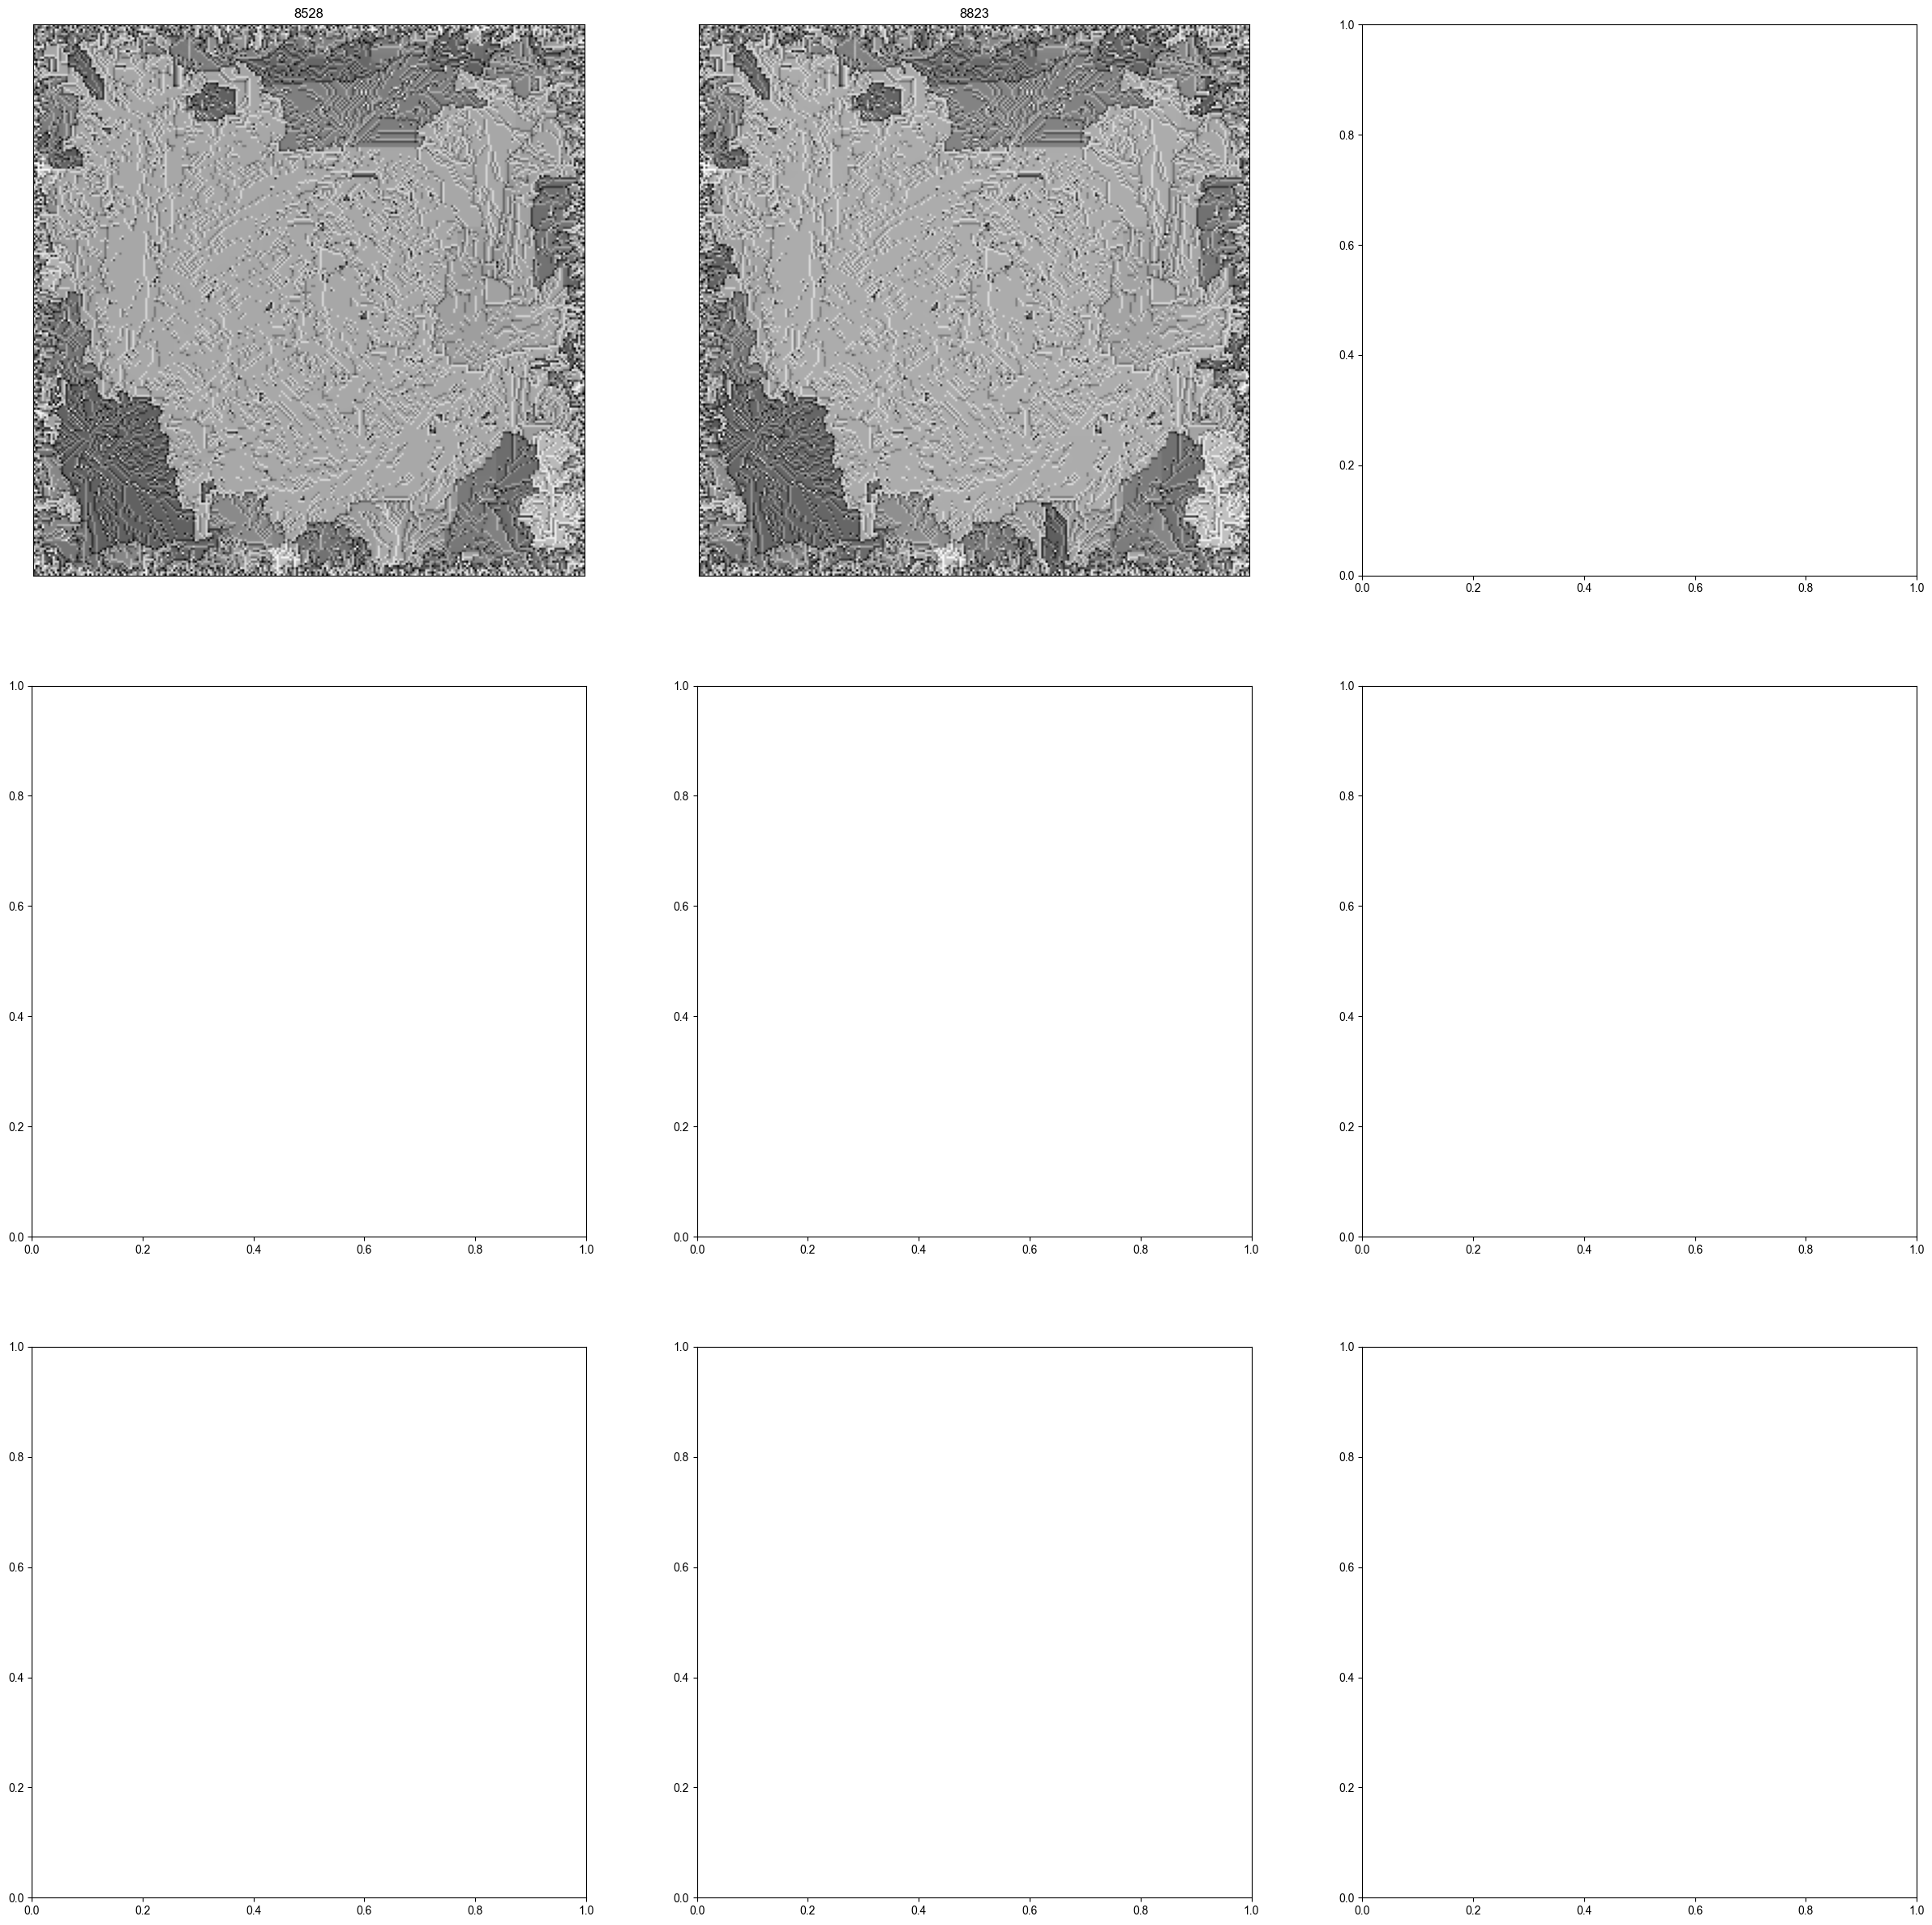

In [ ]:
nb_snap = 9
random_id = np.random.randint(0, len(small_data_not_found)-1, size = nb_snap)
nl = 3
nc = 3

fig, axis = plt.subplots(nl, nc, figsize=(nc * 10 ,nl * 10))
axis = np.array(axis).ravel() # Permet d'avoir une liste plate

# for i, id in enumerate(random_id):
for i, id in enumerate (np.array(small_data_found[:,0])):
    
    file = '{}/Snapshots/nav{}.txt'.format(folder, int(small_data_found[i, 0]))
    snap = np.loadtxt(file, comments='#').reshape(L1, L2).T
    axis[i].imshow(snap, cmap = 'binary')
    
    axis[i].set_xticks([])
    axis[i].set_yticks([])
    axis[i].set_title(int(small_data_found[i, 0]))
    
    if i == nb_snap-1:
        break
plt.show()


fig, axis = plt.subplots(nl, nc, figsize=(nc * 10 ,nl * 10))
axis = np.array(axis).ravel() # Permet d'avoir une liste plate

# for i, id in enumerate(random_id):
for i, id in enumerate (np.array(large_data[:,0])):
    
    file = '{}/Snapshots/nav{}.txt'.format(folder, int(large_data[i, 0]))
    snap = np.loadtxt(file, comments='#').reshape(L1, L2).T
    axis[i].imshow(snap, cmap = 'binary')
    
    axis[i].set_xticks([])
    axis[i].set_yticks([])
    axis[i].set_title(int(large_data[i, 0]))
    
    if i == nb_snap-1:
        break
plt.show()

#   Test N/100, N/10, N/1

## Size pdf 

In [4]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Memory_effects/Me9n{}".format(n) for n in range(1,11)]

nbfolder = len(Tfolderpath)
nbline = 1000
nbcol = 3
data = np.empty((nbfolder,nbline,nbcol))

mask = [8,10,12]
data = [np.loadtxt("{}/random_random.txt".format(folderpath), usecols = mask) for folderpath in Tfolderpath]
data = np.vstack(data)

In [5]:
linhisto_1, linbins_1 = np.histogram(data[:,2], bins = np.arange(1,64*64+1))
linhisto_10, linbins_10 = np.histogram(data[:,1], bins = np.arange(1,64*64+1))
linhisto_100, linbins_100 = np.histogram(data[:,0], bins = np.arange(1,64*64+1))
log_histo_1, log_bins_1 = loghisto(linhisto_1, nbins = 0)
log_histo_10, log_bins_10 = loghisto(linhisto_10, nbins = 0)
log_histo_100, log_bins_100 = loghisto(linhisto_100, nbins = 0)

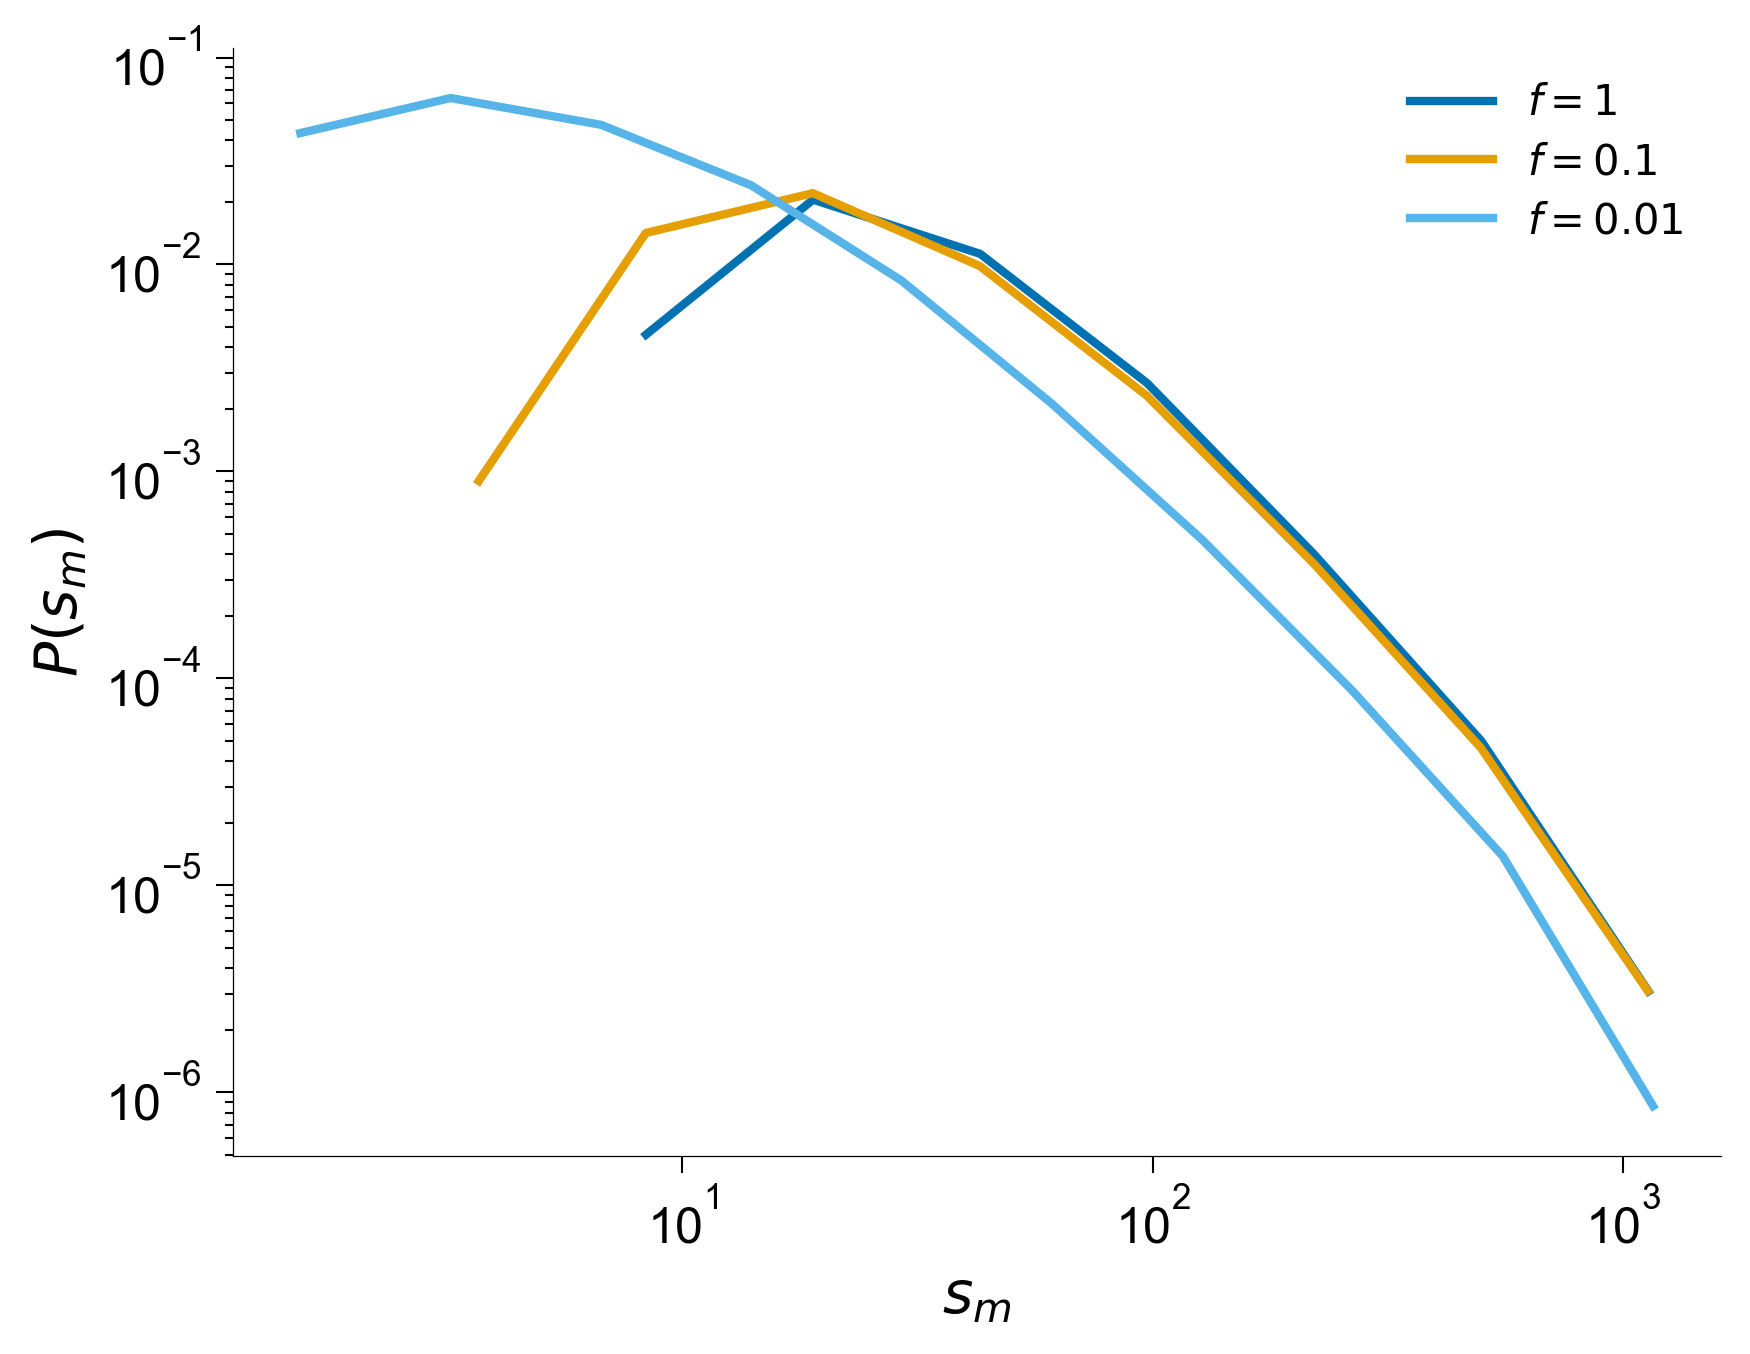

In [10]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    plt.figure()
    plt.plot(log_bins_1, log_histo_1, label = r'$f=1$', c = color_list[0])
    plt.plot(log_bins_10, log_histo_10, label = r'$f=0.1$', c = color_list[1])
    plt.plot(log_bins_100, log_histo_100, label = r'$f=0.01$', c = color_list[2])
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$s_{m}$')
    plt.ylabel(r'$P(s_{m})$')
    plt.legend()

(0.0, 600.0)

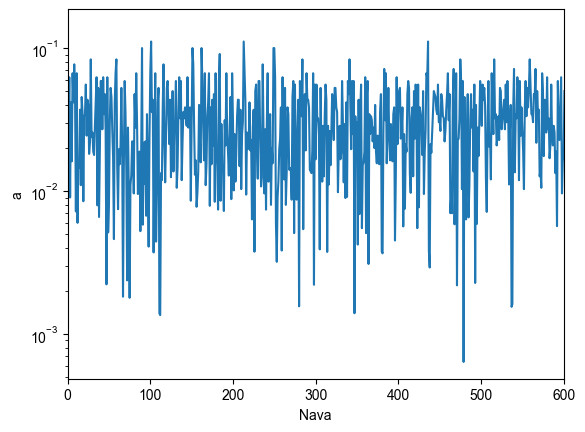

In [ ]:
plt.plot(1/data[:,2])
plt.xlabel("Nava")
plt.ylabel("a")
plt.yscale('log')
plt.xlim(0,600)

#   Verification PDF 10 réal

In [ ]:
def process_parallel_load_file(file, chunksize = 1e6, L = 64, limdata = 1e6, cols = [11]):
    
    bins = np.arange(1,L**2+1)
    histo = np.zeros(len(bins)-1)
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), 50)
    histo_a = np.zeros(len(logbins_a)-1)
    
    nblines = 0
    for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
        histo += np.histogram(chunk.iloc[:, 0], bins = bins)[0]
        histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
        
        nblines += len(chunk)
    
        if nblines >= limdata:
            break
            
    log_histo, log_bins = loghisto(histo)
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    return log_bins, log_histo, logbins_a, norm_histo_a

In [ ]:
nbline = 1.3e7
nu = 0.4
csize = 1e6
L = 64

Tfile = ["/data1/DATA_Duplat/Brut/Memory_effects/Me10n{}/random_random.gz".format(i) for i in range(1,11)] 
results_files = Parallel(n_jobs=-1)(delayed(process_parallel_load_file)(file, csize, L, nbline)
                                  for file in Tfile)

In [ ]:
log_histo_file,log_bins_file = [None] * 10, [None] * 10
logbins_a_file = [None] *10
norm_histo_a_file = [None] * 10

for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results_files):
    log_histo_file[i] = histo_s
    log_bins_file[i] = bins_s
    norm_histo_a_file[i] = hist_a
    logbins_a_file[i] = bins_a

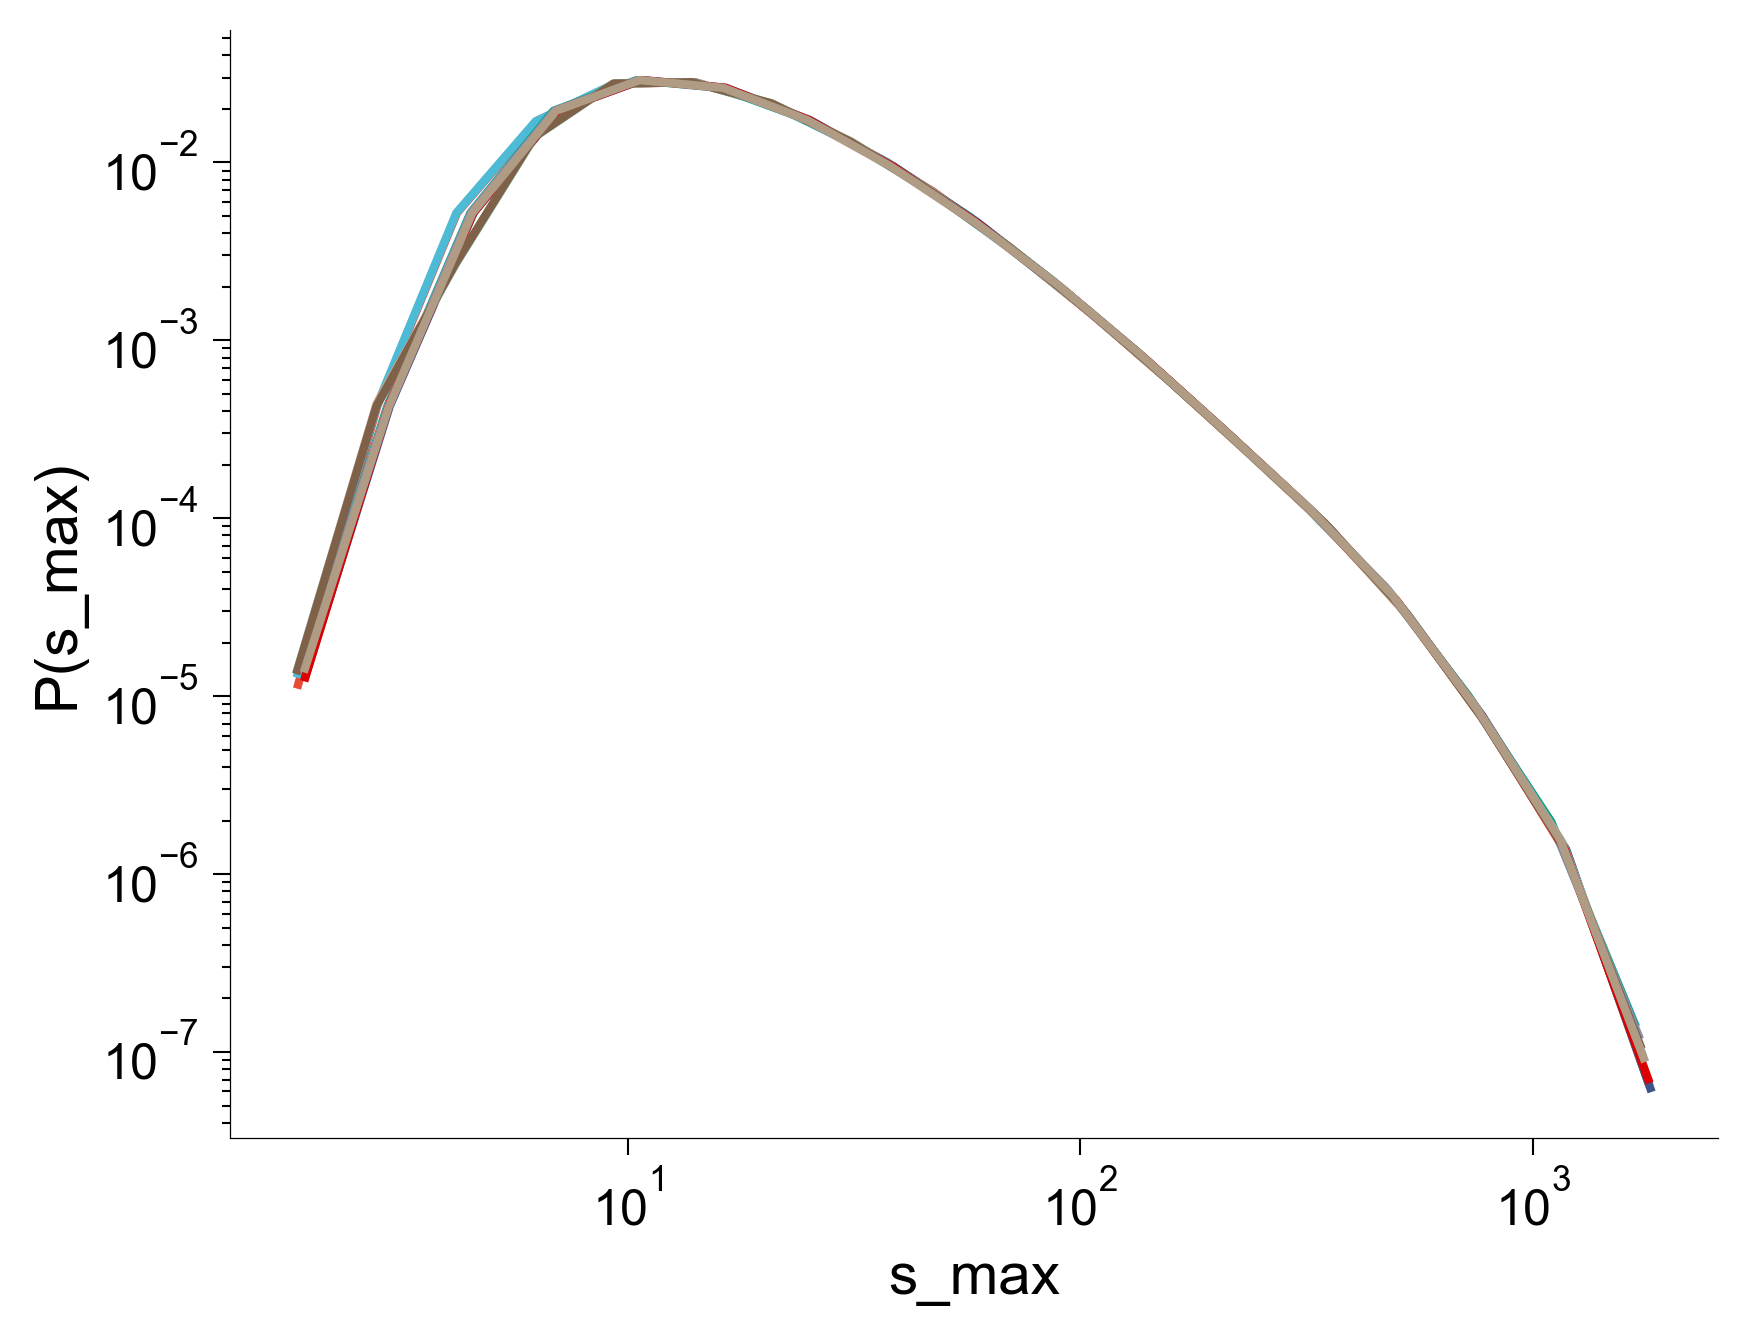

In [ ]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (6.4,4.8))
    for i in range(0,10):
        ax.plot(log_bins_file[i], log_histo_file[i])
        
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel('s_max')
    ax.set_ylabel('P(s_max)')
    

# Susceptibility vs size


In [3]:
for j in [18,10,15,19]:
    for i in range(1,11):
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(j, i)
        print(file, count_lines_gz_safe(file))

/data1/DATA_Duplat/Brut/Memory_effects/Me18n1/random_random.gz 26817407
/data1/DATA_Duplat/Brut/Memory_effects/Me18n2/random_random.gz 22781441
/data1/DATA_Duplat/Brut/Memory_effects/Me18n3/random_random.gz 23423531
/data1/DATA_Duplat/Brut/Memory_effects/Me18n4/random_random.gz 22082617
/data1/DATA_Duplat/Brut/Memory_effects/Me18n5/random_random.gz 26888889
/data1/DATA_Duplat/Brut/Memory_effects/Me18n6/random_random.gz 22010903
/data1/DATA_Duplat/Brut/Memory_effects/Me18n7/random_random.gz 26832121
/data1/DATA_Duplat/Brut/Memory_effects/Me18n8/random_random.gz 27217057
/data1/DATA_Duplat/Brut/Memory_effects/Me18n9/random_random.gz 26617785
/data1/DATA_Duplat/Brut/Memory_effects/Me18n10/random_random.gz 22323852
/data1/DATA_Duplat/Brut/Memory_effects/Me10n1/random_random.gz 21431092
/data1/DATA_Duplat/Brut/Memory_effects/Me10n2/random_random.gz 21458875
/data1/DATA_Duplat/Brut/Memory_effects/Me10n3/random_random.gz 21322059
/data1/DATA_Duplat/Brut/Memory_effects/Me10n4/random_random.gz 

In [36]:
Tnbline = [2.2e7, 1.8e7, 6e5, 3e3]
Tnu = [0.4, 0.4, 0.4, 0.4]
csize = [1e6] * 2 + [1e5] + [1e3]
TL = [32, 64,128, 256]

folder_nb = [18,10,15, 19]
results_size_scaling = Parallel(n_jobs=-1)(delayed(process_parallel_load)(j, csize, L, nbline)
                                  for (j, csize, L, nbline) in zip(folder_nb, csize, TL, Tnbline))

In [37]:
log_histo,log_bins = [None] *len(Tnu), [None] *len(Tnu)
logbins_a = [None] *len(Tnu)
norm_histo_a = [None] * len(Tnu)

for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results_size_scaling):
    log_histo[i] = histo_s
    log_bins[i] = bins_s
    norm_histo_a[i] = hist_a
    logbins_a[i] = bins_a

print(log_bins[-1])
bin_centers_s = [(bins[:-1] + bins[1:])/2 for bins in log_bins]
bin_centers_a = [(bins[:-1] + bins[1:])/2 for bins in logbins_a]


[1.00000000e+00 1.68396776e+00 2.83574743e+00 4.77530725e+00
 8.04146346e+00 1.35415652e+01 2.28035593e+01 3.84004588e+01
 6.46651346e+01 1.08894002e+02 1.83373989e+02 3.08795886e+02
 5.20002317e+02 8.75667139e+02 1.47459523e+03 2.48317083e+03
 4.18157963e+03 7.04164530e+03 1.18579037e+04 1.99683275e+04
 3.36260198e+04 5.66251334e+04 9.53548992e+04 1.60574576e+05
 2.70402410e+05 4.55348941e+05 7.66792938e+05 1.29125459e+06
 2.17443110e+06 3.66167187e+06 6.16613739e+06 1.03835766e+07
 1.74856082e+07 2.94452006e+07 4.95847685e+07 8.34991517e+07
 1.40609880e+08 2.36782505e+08 3.98734104e+08 6.71455378e+08
 1.13070921e+09 1.90407786e+09 3.20640573e+09 5.39948389e+09
 9.09255680e+09 1.53115725e+10 2.57841945e+10 4.34197524e+10
 7.31174633e+10 1.23127451e+11]


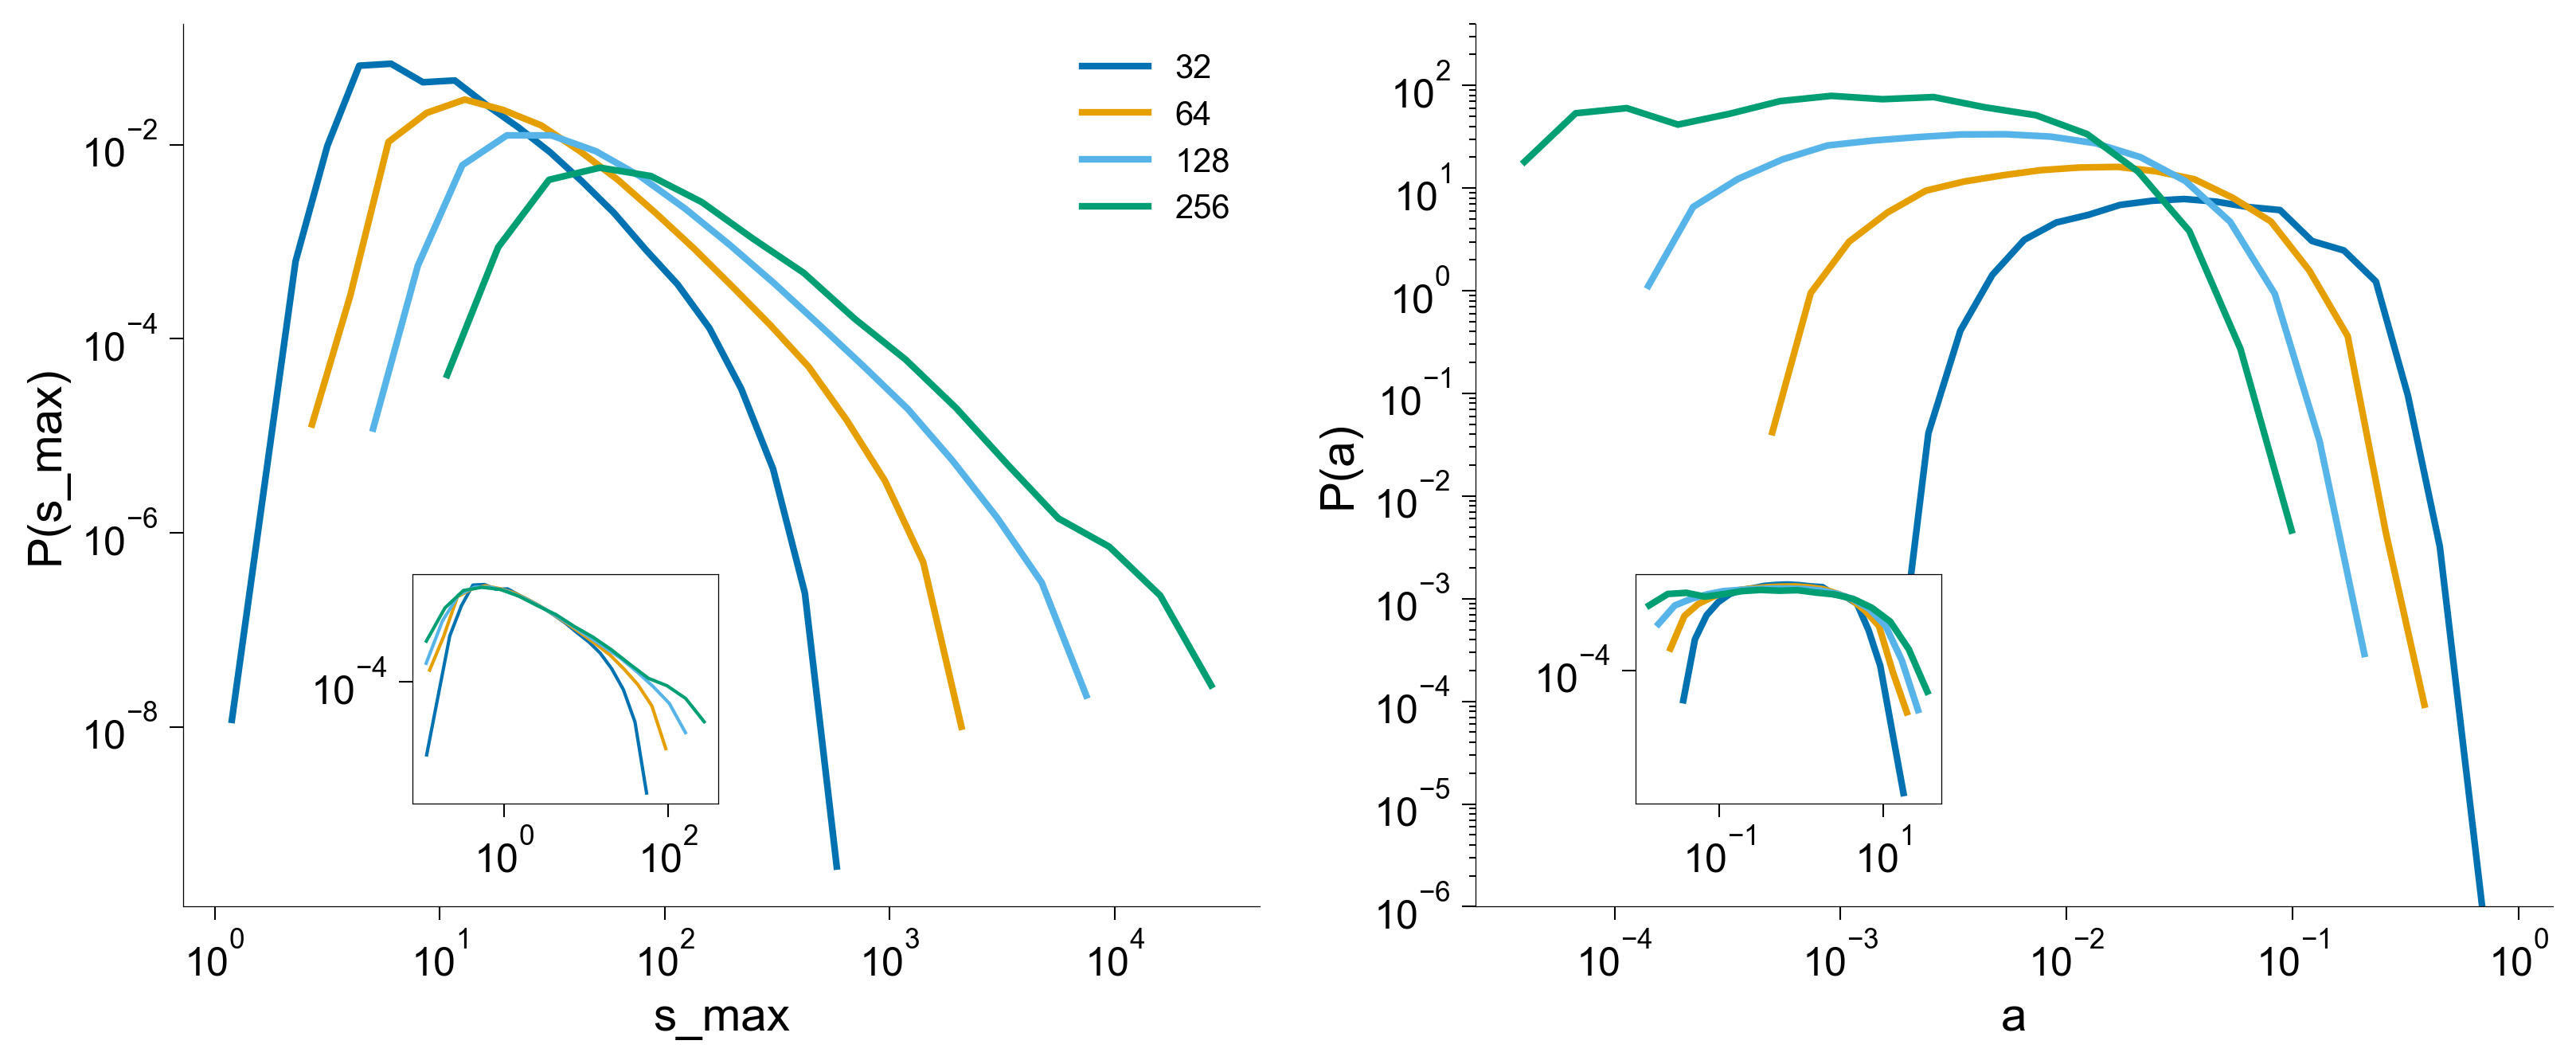

In [39]:
NCURVES = len(Tnu) -1
color = [plt.cm.get_cmap('viridis')(1 - i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax, ax2) = plt.subplots(1,2, figsize = (12.8,4.8))
    ax12 = fig.add_axes([0.2,0.2,0.1,0.2])
    
    for j, n in enumerate([18,10,15,19]):
        mask = log_histo[j]!=0
        mean = np.sum(bin_centers_s[j] * log_histo[j]) / np.sum(log_histo[j])
        
        ax.plot(bin_centers_s[j][mask], log_histo[j][mask], c = color_list[j], label = TL[j])
        ax12.plot(bin_centers_s[j][mask]/mean, log_histo[j][mask] *mean, lw = 1, c = color_list[j])

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax12.set_yscale('log')
    ax12.set_xscale('log')
    ax12.spines['top'].set_visible(True)
    ax12.spines['right'].set_visible(True)
    # ax2.set_ylim(1e-8, 10)
    ax.set_xlabel('s_max')
    ax.set_ylabel('P(s_max)')
    ax.legend(loc = "upper right")

    alpha = -0.1     # ~flat in log-log
    x_min = 1e-4
    x_max = 1e-1
    A = 10.0


    ax22 = fig.add_axes([0.6,0.2,0.1,0.2])
    for j, n in enumerate([18,10,15,19]):
        mask = norm_histo_a[j]!=0
        
        ax2.plot(bin_centers_a[j][mask], norm_histo_a[j][mask], c = color_list[j])
        
        mean = np.sum(norm_histo_a[j][mask] * bin_centers_a[j][mask]) / np.sum(norm_histo_a[j][mask])
        ax22.plot(bin_centers_a[j][mask]/mean, norm_histo_a[j][mask]*mean, c = color_list[j])
        
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax22.set_xscale('log')
    ax22.set_yscale('log')
    ax2.set_xlabel('a')
    ax2.set_ylabel('P(a)')
    ax2.set_ylim(1e-6, 400)
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    # plt.xlim(3e-4, 2e-2)
    # ax2.legend()

    plt.show()

# Nb of toppling effect

In [29]:
for j in [16,13]:
    for i in range(1,11):
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(j, i)
        print(file, count_lines_gz_safe(file))

/data1/DATA_Duplat/Brut/Memory_effects/Me16n1/random_random.gz 651035
/data1/DATA_Duplat/Brut/Memory_effects/Me16n2/random_random.gz 608601
/data1/DATA_Duplat/Brut/Memory_effects/Me16n3/random_random.gz 906346
/data1/DATA_Duplat/Brut/Memory_effects/Me16n4/random_random.gz 622702


KeyboardInterrupt: 

In [31]:
Tnbline = [5e5, 6e6]
Tnu = [0.2, 0.2]
csize = [1e5, 1e6]
TL = [64,64]

folder_nb = [16,13]
results_nb_top = Parallel(n_jobs=-1)(delayed(process_parallel_load)(j, csize, L, nbline)
                                  for (j, csize, L, nbline) in zip(folder_nb, csize, TL, Tnbline))

In [33]:
log_histo,log_bins = [None] *len(Tnu), [None] *len(Tnu)
logbins_a = [None] *len(Tnu)
norm_histo_a = [None] * len(Tnu)

for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results_nb_top):
    log_histo[i] = histo_s
    log_bins[i] = bins_s
    norm_histo_a[i] = hist_a
    logbins_a[i] = bins_a

print(log_bins[-1])
bin_centers_s = [(bins[:-1] + bins[1:])/2 for bins in log_bins]
bin_centers_a = [(bins[:-1] + bins[1:])/2 for bins in logbins_a]

[1.00000000e+00 1.47825831e+00 2.18524764e+00 3.23036049e+00
 4.77530725e+00 7.05913764e+00 1.04352289e+01 1.54259639e+01
 2.28035593e+01 3.37095511e+01 4.98314242e+01 7.36637170e+01
 1.08894002e+02 1.60973464e+02 2.37960361e+02 3.51766882e+02
 5.20002317e+02 7.68697748e+02 1.13633384e+03 1.67979494e+03
 2.48317083e+03 3.67076793e+03 5.42634321e+03 8.02153695e+03
 1.18579037e+04 1.75290447e+04 2.59124560e+04 3.83053035e+04
 5.66251334e+04 8.37065742e+04 1.23739939e+05 1.82919594e+05
 2.70402410e+05 3.99724610e+05 5.90896228e+05 8.73497261e+05
 1.29125459e+06 1.90880783e+06 2.82171104e+06 4.17121780e+06
 6.16613739e+06 9.11514386e+06 1.34745372e+07 1.99188466e+07
 2.94452006e+07 4.35276125e+07 6.43450551e+07 9.51186126e+07
 1.40609880e+08 2.07857724e+08]


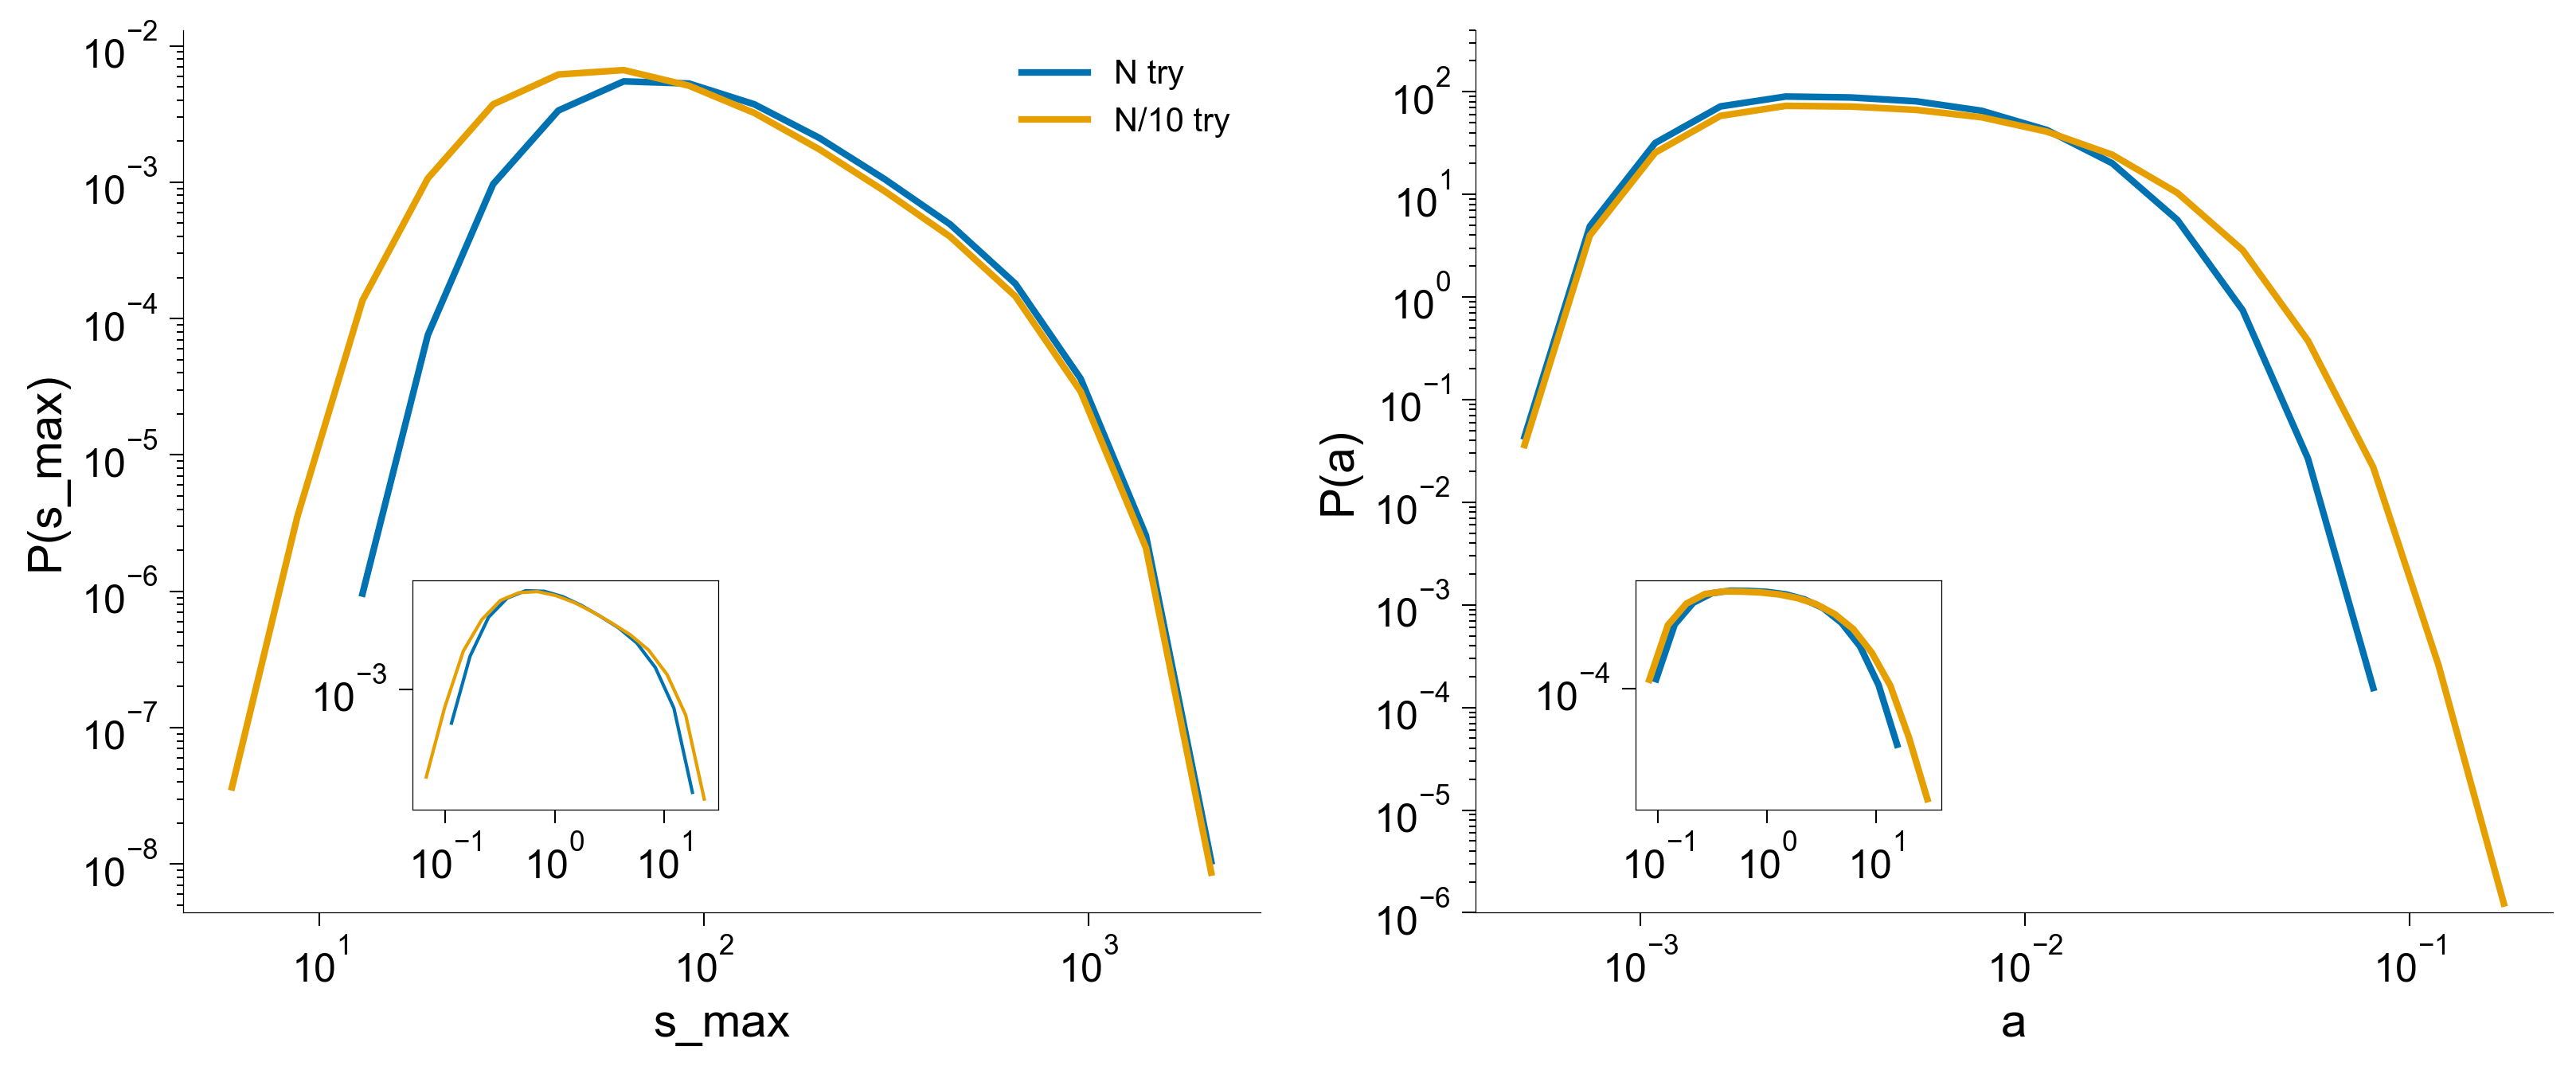

In [35]:
NCURVES = len(Tnu) -1
color = [plt.cm.get_cmap('viridis')(1 - i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax, ax2) = plt.subplots(1,2, figsize = (12.8,4.8))
    ax12 = fig.add_axes([0.2,0.2,0.1,0.2])
    
    for j, n in enumerate([16,13]):
        mask = log_histo[j]!=0
        mean = np.sum(bin_centers_s[j] * log_histo[j]) / np.sum(log_histo[j])
        
        if j == 0:
            ax.plot(bin_centers_s[j][mask], log_histo[j][mask], c = color_list[j], label ='N try')
        else:
            ax.plot(bin_centers_s[j][mask], log_histo[j][mask], c = color_list[j], label ='N/10 try')
        ax12.plot(bin_centers_s[j][mask]/mean, log_histo[j][mask] *mean, lw = 1, c = color_list[j])

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax12.set_yscale('log')
    ax12.set_xscale('log')
    ax12.spines['top'].set_visible(True)
    ax12.spines['right'].set_visible(True)
    # ax2.set_ylim(1e-8, 10)
    ax.set_xlabel('s_max')
    ax.set_ylabel('P(s_max)')
    ax.legend(loc = "upper right")

    alpha = -0.1     # ~flat in log-log
    x_min = 1e-4
    x_max = 1e-1
    A = 10.0


    ax22 = fig.add_axes([0.6,0.2,0.1,0.2])
    for j, n in enumerate([16,13]):
        mask = norm_histo_a[j]!=0
        
        ax2.plot(bin_centers_a[j][mask], norm_histo_a[j][mask], c = color_list[j])
        
        mean = np.sum(norm_histo_a[j][mask] * bin_centers_a[j][mask]) / np.sum(norm_histo_a[j][mask])
        ax22.plot(bin_centers_a[j][mask]/mean, norm_histo_a[j][mask]*mean, c = color_list[j])
        
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax22.set_xscale('log')
    ax22.set_yscale('log')
    ax2.set_xlabel('a')
    ax2.set_ylabel('P(a)')
    ax2.set_ylim(1e-6, 400)
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    # plt.xlim(3e-4, 2e-2)
    # ax2.legend()

    plt.show()

# Pour L = 256 Après la correction du code

In [3]:
Tfolder_nb = [77,78,79,80,81,83,82]
nbfolder = 9
count_lines(Tfolder_nb, 9)

4687
40102
51832
41540
39543
34025
52208


In [4]:
# Tfolder_nb = [69, 70, 71, 72, 73, 74, 75, 76]
Tfolder_nb = [77,78,79,80,81,83, 82]
# Tfolder_nb = [65]
Tbin_s1, Thisto_s1, Tbin_a1, Thisto_a1 = full_analysis(Tfolder_nb, nbfolder = [2,3,4,5,6,7,8,9], nbins = 50, cols =[12])

7000
75000
80000
80000
78000
34000
70000


In [5]:
Tnu_th, Tgamma_th = gamma_th()

0.9732357584940278
0.9975324494719886
0.9843991776279883
0.9970859311888708
0.9967113314349261
0.9908589821737359
0.9876873752229091
0.9305691822966923
0.9157895180835686
0.9717682300108818
0.8966998473392582
0.9036335250896846
0.8816068227366466
0.9039939370639607


<ipython-input-2-ba81bbf5a919>:212: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_s, Tbins_s, _, _,_ = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))


In [6]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]

Thisto_s, Tbins_s, Tnonzero_s, Tmean_s,Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                    for  folder in folderpath)).T

Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)

<ipython-input-6-6103bc200efc>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_s, Tbins_s, Tnonzero_s, Tmean_s,Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))


0.9732357584940278
0.9975324494719886
0.9843991776279883
0.9970859311888708
0.9967113314349261
0.9908589821737359
0.9876873752229091
0.9305691822966923
0.9157895180835686
0.9717682300108818
0.8966998473392582
0.9036335250896846
0.8816068227366466
0.9039939370639607


1
2
3
4
5
6


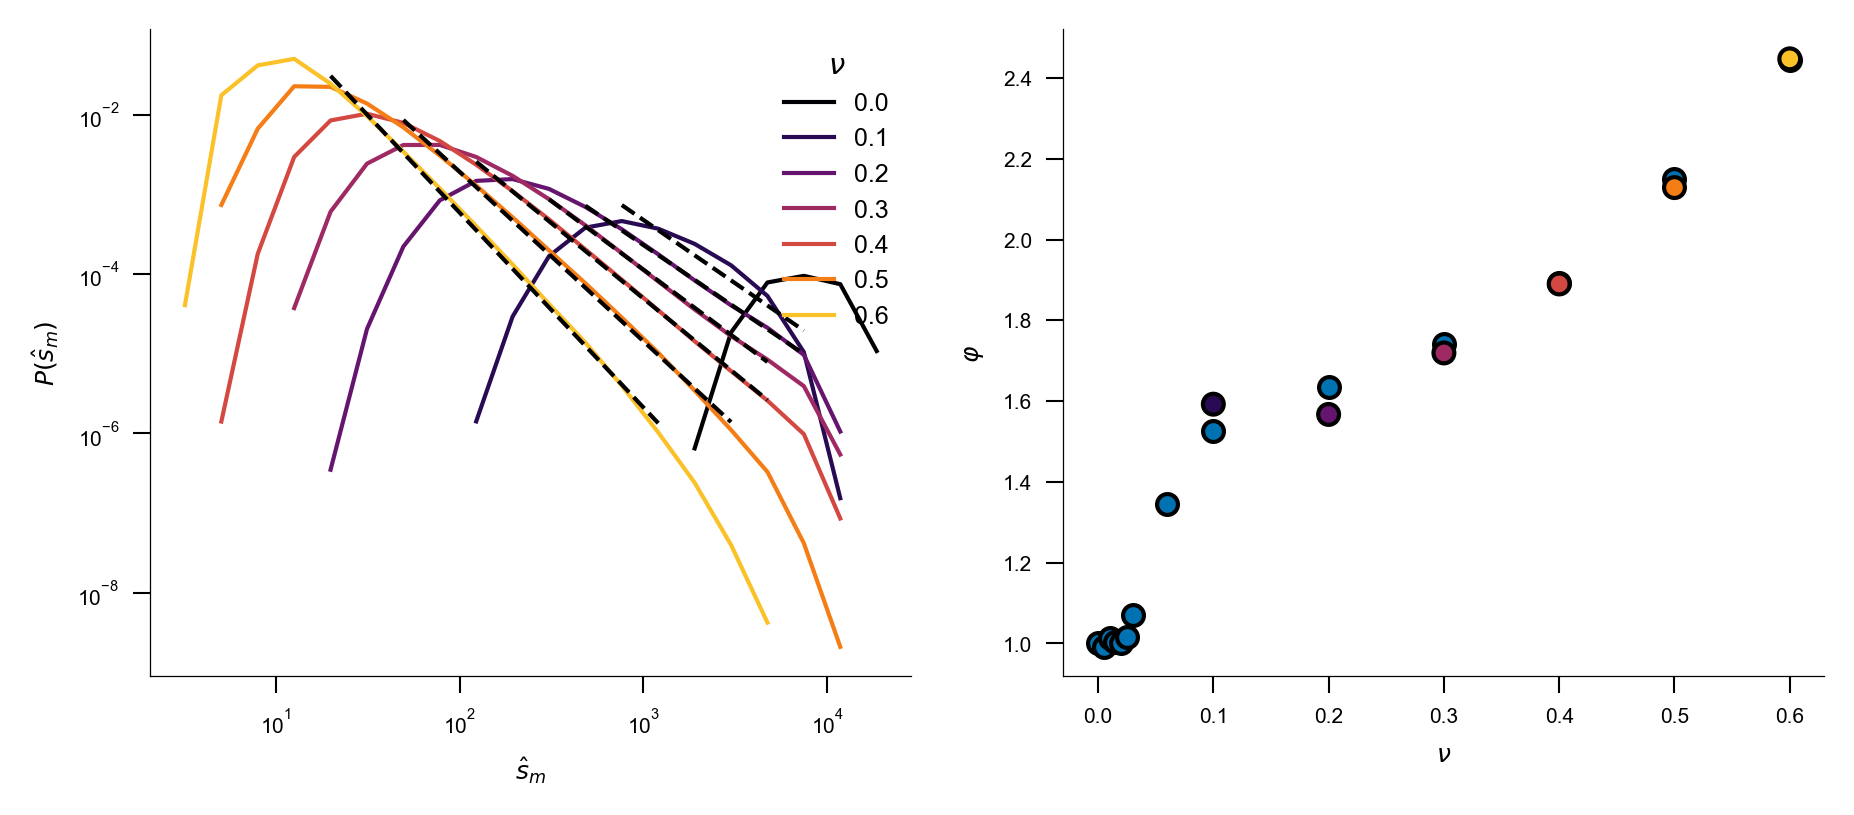

In [20]:
Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 3e4, 2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 5e2, 400, 200, 100, 40, 15]

Tperr= [0]*len(Tnu)
Ttau = [0]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax, ax2) = plt.subplots(1,2,figsize = (7.2,2.8))

    for j, n in enumerate(Tnu[:]):
            
        ax.plot(Tbin_s1[j], Thisto_s1[j], c = Tcolor[j], label = f"{Tnu[j]}")
        
        """ if j not in [0, 1]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop_j = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            print(j)
            popt, pcov = curve_fit(log_exppowlaw, Tbin_s1[j][start:], np.log(Thisto_s1[j][start:]), p0 = [0.5, 1.6, 10], maxfev = 1000)
            tau = popt[1]
            Tperr[j] = np.sqrt(np.diag(pcov))[1]
            Ttau[j] = -tau
            yfit = np.exp(log_exppowlaw(Tbin_s1[j][start:], *popt))
            ax.plot(Tbin_s1[j][start:], yfit, ls = '--', c ='k', lw =1) """

        """ if j not in [0, 1]:
            result, xs, ys , perr = fit_powerlaw(Tbin_s1[j], Thisto_s1[j], stop_x = Tstop[j], start_x = Tstart[j], switch = 1,  plot=True, f_scale=1.0,
                                        function_to_fit='power')
            Ttau[j] = result.x[1]
            Tperr[j] = perr[1]
            yfit = powerlaw(xs, *result.x) 
            ax.plot(xs, yfit, ls = '--', c ='k', lw =1) """
            
        if j not in [0]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            print(j)
            popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
            tau = popt[1]
            Tperr[j] = np.sqrt(np.diag(pcov))[1]
            Ttau[j] = tau
            yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
            ax.plot(Tbin_s1[j][start:stop], yfit, ls = '--', c ='k', lw =1)
            
        
        
    ax2.scatter(Tnu_th, 2-(-Tgamma_th), c = color_list[0])
    mask = Ttau !=0
    ax2.scatter(Tnu[1:], (-np.array(Ttau)[1:]), c = Tcolor[1:])
    # ax2.errorbar(Tnu[1:], (-np.array(Ttau)[1:]), yerr = Tperr[1:], color = 'k', zorder=2)
    # ax2.scatter(Tvar, (-Ttau_s), c = color_list[1])
    ax2.set_xlabel(r"$\nu$")
    ax2.set_ylabel(r"$\varphi$")
            
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\hat s_m$')
    ax.set_ylabel(r'$P(\hat s_m)$')
    ax.legend(loc = "upper right", title = r"$\nu$")

    plt.show()

#   Distance to criticality from theory 

En réfléchissant un peu on a trouver que $a= s^{(\tau _0 -1)/(\tau _0 - \tau)}$

In [15]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]
Thisto_s, Tbins_s, _, _,_ = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)).T

Tstop_x = [4.e3, 1e-8, 7e-10,  1.1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-9, 5e-11, 1e-11]
Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
_, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)

Ttau_s = -np.array(Ttau_s)

0.9744842492244239
0.9986543843464805
0.9918982164774093
0.9980961044125023
0.9968311839581544
0.9920471418833141
0.9903840321678057
0.9250421215159194
0.9154873870853011
0.9716926031017113
0.8961760168187342
0.903939923589345
0.8709261132810331
0.8955929085017476


<ipython-input-15-881ae7839921>:4: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_s, Tbins_s, _, _,_ = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))


[ 1.000e-05  1.000e-05 -1.000e-03  1.000e-05  1.000e-05 -2.000e-02
 -7.800e-02 -3.500e-01 -5.260e-01 -6.360e-01 -7.420e-01 -8.900e-01
 -1.141e+00 -1.425e+00]
[ 1.000e-05  1.000e-05 -1.000e-03  1.000e-05  1.000e-05 -2.000e-02
 -7.800e-02 -3.500e-01 -5.260e-01 -6.360e-01 -7.420e-01 -8.900e-01
 -1.141e+00 -1.425e+00]
[ 1.000e-05  1.000e-05 -1.000e-03  1.000e-05  1.000e-05 -2.000e-02
 -7.800e-02 -3.500e-01 -5.260e-01 -6.360e-01 -7.420e-01 -8.900e-01
 -1.141e+00 -1.425e+00]
[ 1.000e-05  1.000e-05 -1.000e-03  1.000e-05  1.000e-05 -2.000e-02
 -7.800e-02 -3.500e-01 -5.260e-01 -6.360e-01 -7.420e-01 -8.900e-01
 -1.141e+00 -1.425e+00]
[ 1.000e-05  1.000e-05 -1.000e-03  1.000e-05  1.000e-05 -2.000e-02
 -7.800e-02 -3.500e-01 -5.260e-01 -6.360e-01 -7.420e-01 -8.900e-01
 -1.141e+00 -1.425e+00]


<ipython-input-40-fbced39a2522>:16: RuntimeWarning: overflow encountered in power
  a = s**((Ttau_s[0] - 1)/denom)


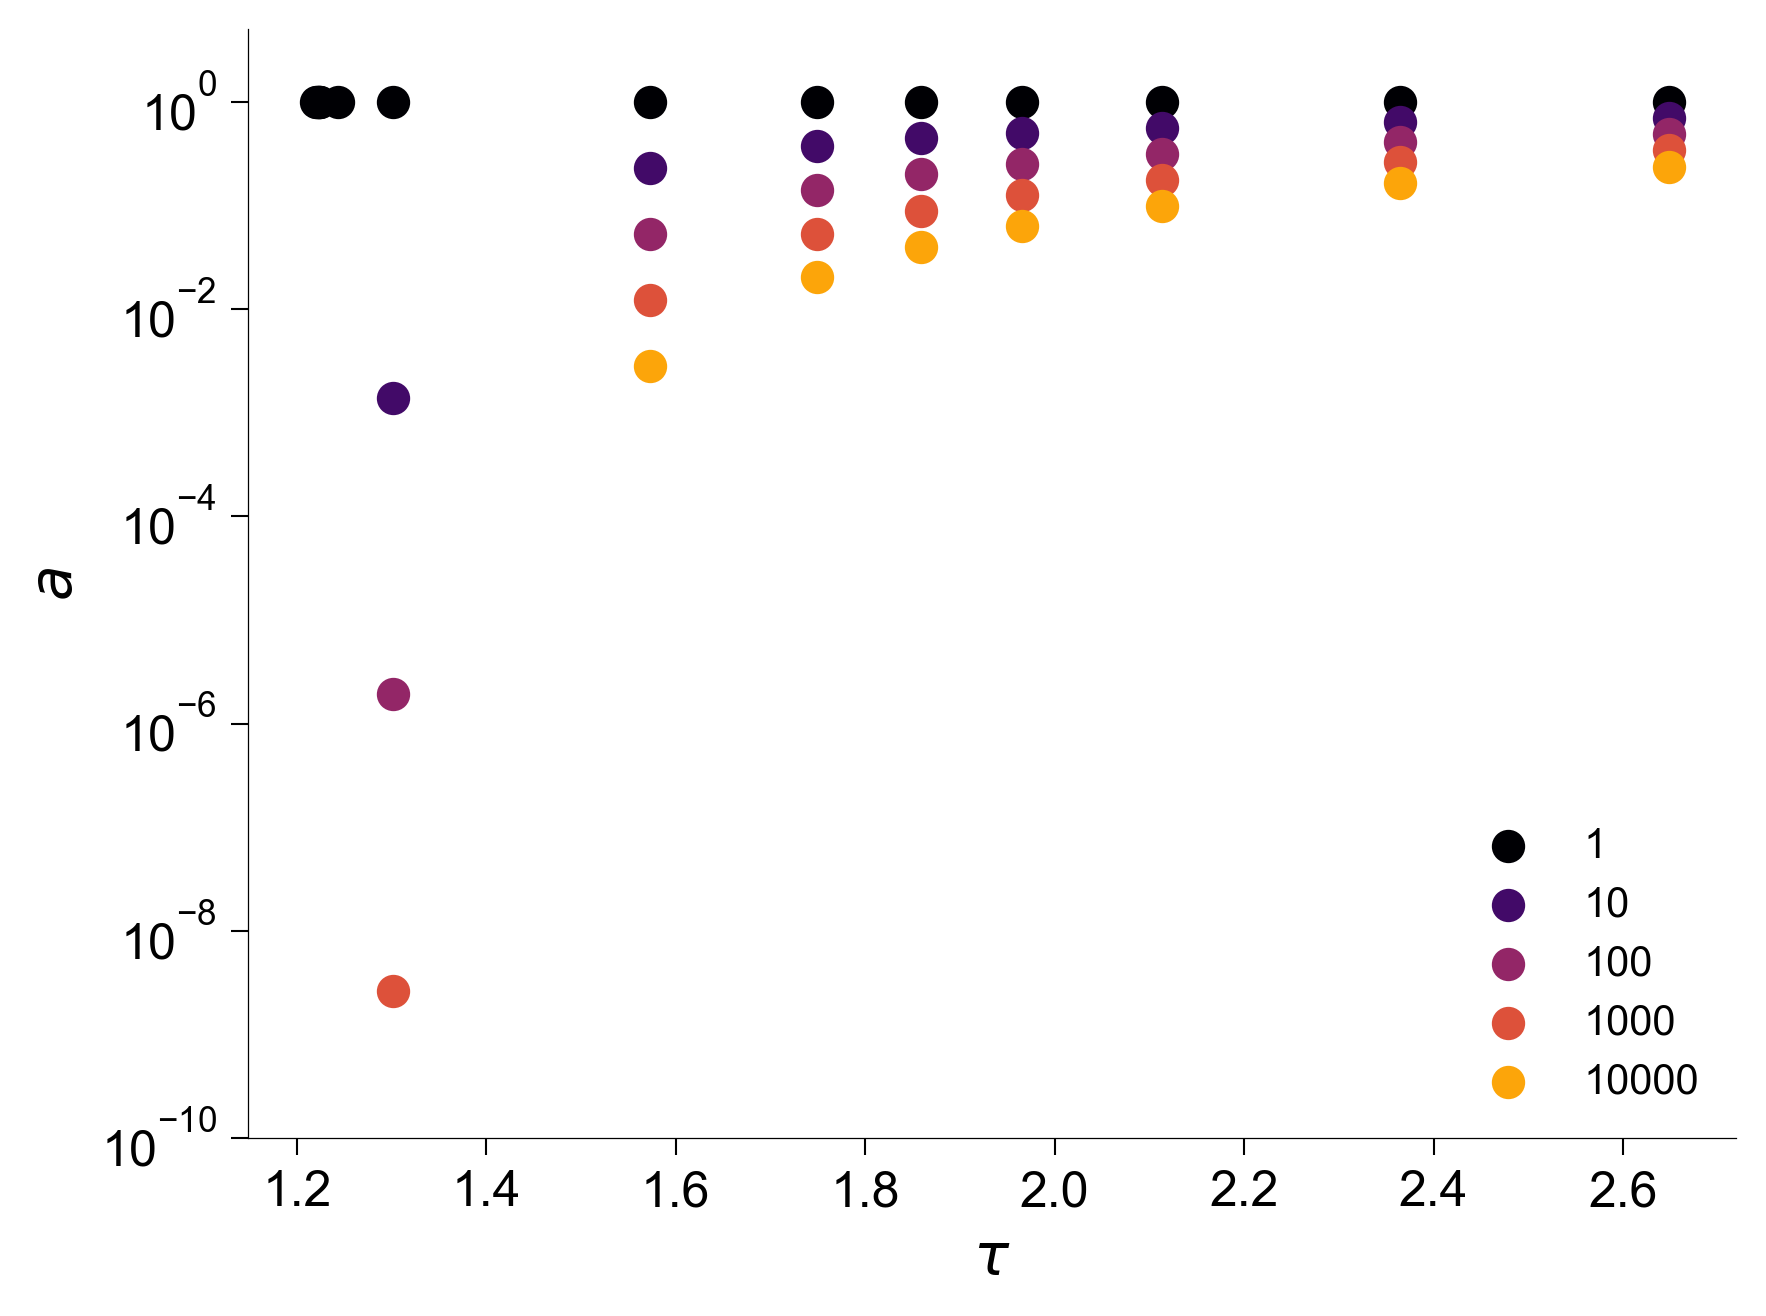

In [40]:
Ts = np.array([1,10,100,1000,10000])

NCURVES = len(Ts)
color = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(1,1,figsize = (6.4,4.8))
    
    for i, s  in enumerate(Ts[:]):
        
        denom = Ttau_s[0] - Ttau_s
        
        denom[denom >= 0] = 0.00001
        print(denom)
        a = s**((Ttau_s[0] - 1)/denom)
        ax.scatter(Ttau_s, a, color = color[i], label = s)
        
    ax.set_yscale('log')
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$a$")
    ax.set_ylim(1e-10, 5)
    ax.legend()
    



#   P(s|sc)

In [130]:
def process_parallel_load(foldernb, nb = 11, chunksize = 1e6, L = 64, limdata = 1e6, cols = [4, 12], nbins = 50, sc_min = 0, sc_max = 1e6):

    logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    histo_s = np.zeros(len(logbins_s)-1)
    
    for i in range(1,nb+1):
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                mask = (chunk.iloc[:, 1] >= sc_min) and (chunk.iloc[:, 1] >= sc_max)
                histo_s += np.histogram(chunk.iloc[:, 0][mask], bins = logbins_s)[0]
                
                nblines += len(chunk[:,0])
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s = int(float(line.strip().split()[cols[0]]))
                    sc = int(float(line.strip().split()[cols[1]]))
                    if (sc_min <= sc <= sc_max):
                        id = np.searchsorted(logbins_s, s, side='right') -1
                        histo_s[id] += 1
                    
                    if i >= limdata:
                        break
    norm_histo_s = histo_s/((np.diff(logbins_s)) * np.sum(histo_s))
    
    return logbins_s, norm_histo_s
    
def full_analysis(Tfolder_nb, nbins = 50, cols = [4,12], nbfolder = 10, sc_min = 0 , sc_max = 1e6): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in range(1,(nbfolder +1)):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins, sc_min =sc_min, sc_max = sc_max)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])

    return f_bin_centers_s, f_log_histo

In [133]:
# Tfolder_nb = [77,78,79,80,81,83, 82]
Tfolder_nb = [80]
Tbin_s1, Thisto_s1 = full_analysis(Tfolder_nb, nbfolder = 9, nbins = 100, sc_min = 1e3, sc_max = 3e3)
Tbin_s2, Thisto_s2 = full_analysis(Tfolder_nb, nbfolder = 9, nbins = 100, sc_min = 1e1, sc_max = 3e1)
Tbin_s3, Thisto_s3 = full_analysis(Tfolder_nb, nbfolder = 9, nbins = 100, sc_min = 1e2, sc_max = 3e2)

0


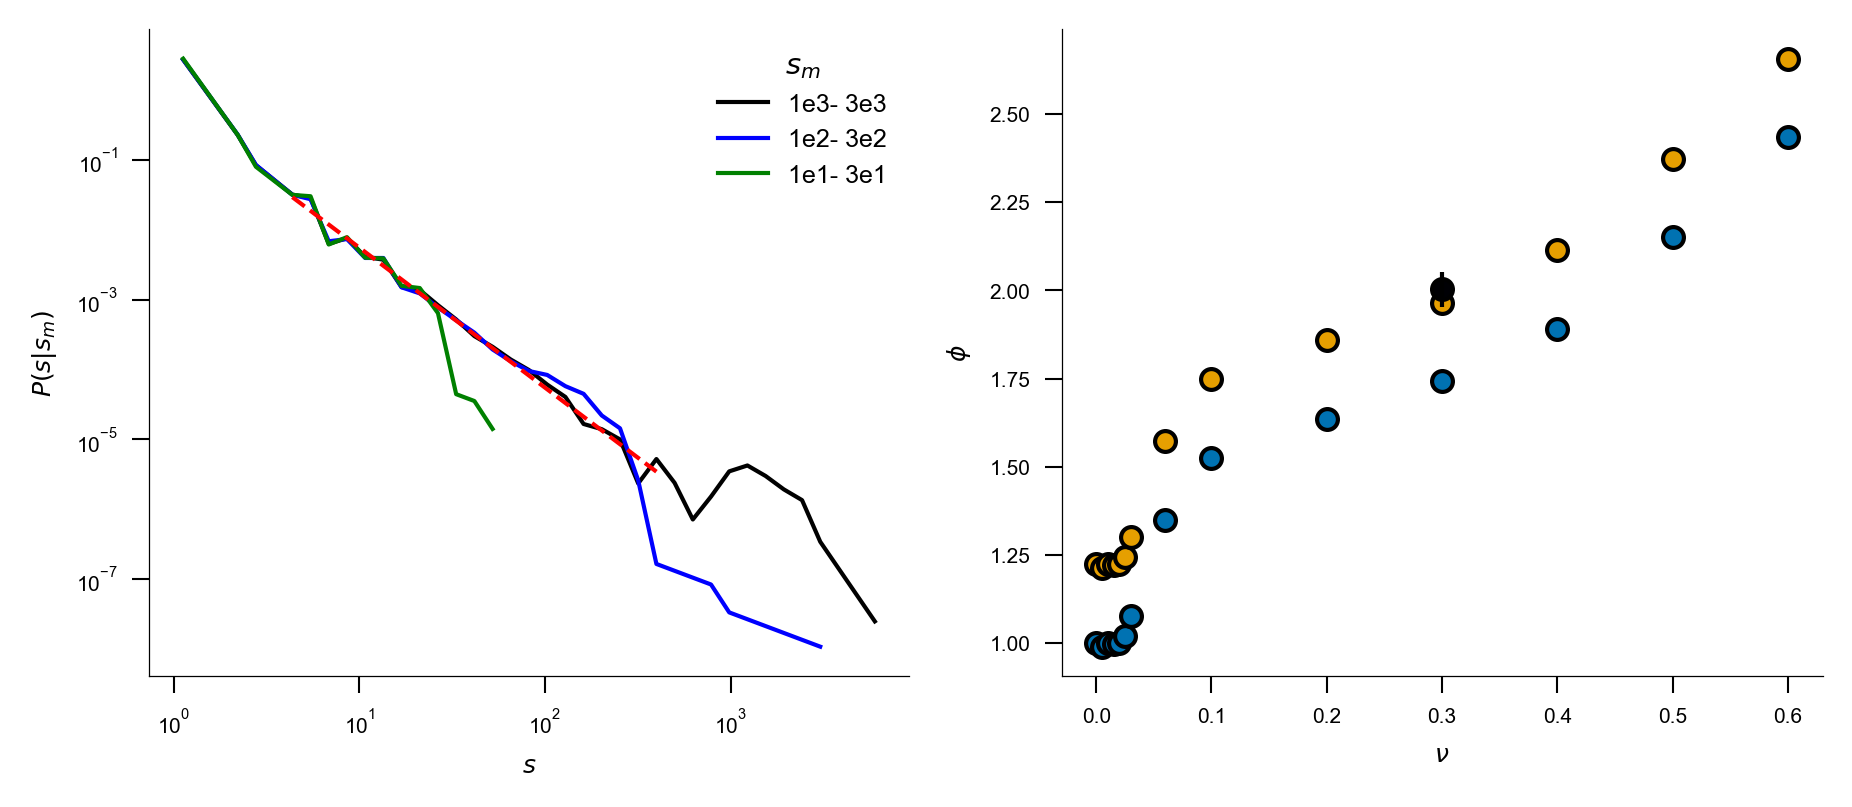

In [ ]:
Tnu = [0.3]
Tn_try = [1]*len(Tnu)
Tstop = [5e2]
Tstart = [3]

Tperr= [0]*len(Tnu)
Ttau = [0]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax, ax2) = plt.subplots(1,2,figsize = (7.2,2.8))

    for j, n in enumerate(Tnu[:]):
            
        ax.plot(Tbin_s1[j], Thisto_s1[j], c = 'k', label = f"1e3- 3e3")
        ax.plot(Tbin_s3[j], Thisto_s3[j], c = 'b', label = f"1e2- 3e2")
        ax.plot(Tbin_s2[j], Thisto_s2[j], c = 'g', label = f"1e1- 3e1")
        
        
        """ if j not in [0, 1]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop_j = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            print(j)
            popt, pcov = curve_fit(log_exppowlaw, Tbin_s1[j][start:], np.log(Thisto_s1[j][start:]), p0 = [0.5, 1.6, 10], maxfev = 1000)
            tau = popt[1]
            Tperr[j] = np.sqrt(np.diag(pcov))[1]
            Ttau[j] = -tau
            yfit = np.exp(log_exppowlaw(Tbin_s1[j][start:], *popt))
            ax.plot(Tbin_s1[j][start:], yfit, ls = '--', c ='k', lw =1) """

        """ if j not in [0, 1]:
            result, xs, ys , perr = fit_powerlaw(Tbin_s1[j], Thisto_s1[j], stop_x = Tstop[j], start_x = Tstart[j], switch = 1,  plot=True, f_scale=1.0,
                                        function_to_fit='power')
            Ttau[j] = result.x[1]
            Tperr[j] = perr[1]
            yfit = powerlaw(xs, *result.x) 
            ax.plot(xs, yfit, ls = '--', c ='k', lw =1) """

        start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
        stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
        print(j)
        popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
        tau = popt[1]
        Tperr[j] = np.sqrt(np.diag(pcov))[1]
        Ttau[j] = tau
        yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
        ax.plot(Tbin_s1[j][start:stop], yfit, ls = '--', c ='r', lw =1)
            
        
    ax2.scatter(Tvar, (-Ttau_s), c = color_list[1])
    ax2.scatter(Tnu_th, 2-(-Tgamma_th), c = color_list[0])
    mask = Ttau !=0
    ax2.scatter(Tnu, (-np.array(Ttau)), c = Tcolor)
    ax2.errorbar(Tnu, (-np.array(Ttau)), yerr = Tperr, color = 'k', zorder=2)
    
    ax2.set_xlabel(r"$\nu$")
    ax2.set_ylabel(r"$\varphi$")
            
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s|s_m)$')
    ax.legend(loc = "upper right", title = r"$s_m$")

    plt.show()

#   Analyse Rd9

##   Histo P(s*)

In [3]:
folder = '/data1/DATA_Duplat/Brut/Rdtopple/Rd9n6'
L1 = 256
L2 = 256
nbmaxtry = 6554

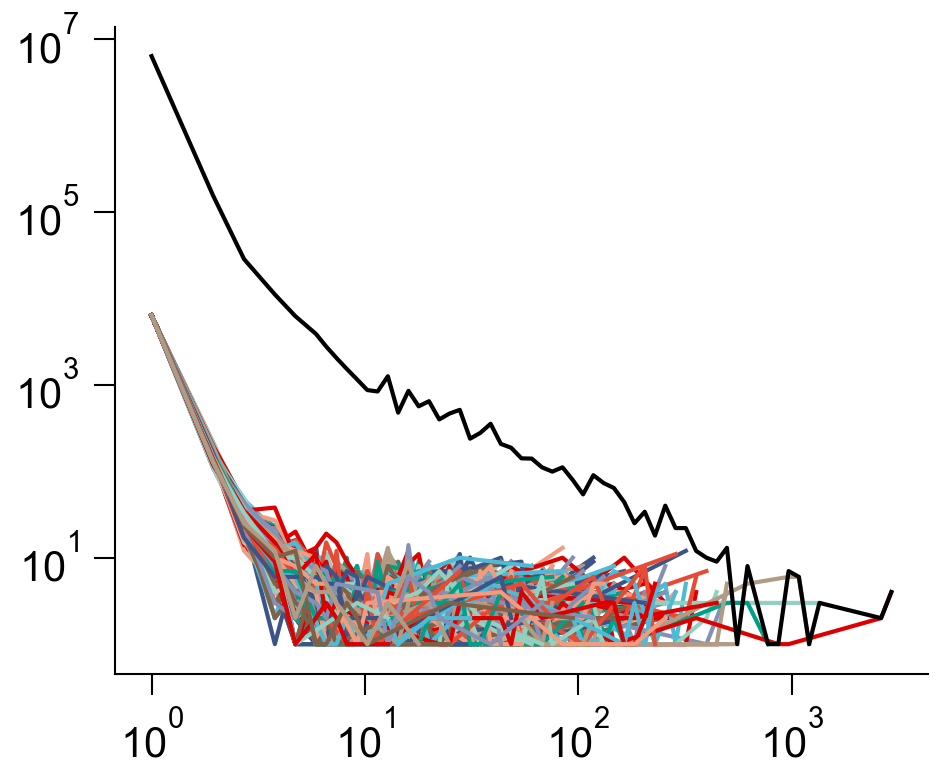

In [211]:
data = np.loadtxt("{}/random_histo_si.txt".format (folder))

nbins = 100

bins = np.logspace(np.log10(1), np.log10(L1*L2), nbins +1)

with plt.style.context(spstyle.get_style('thesis')):
    
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    sum_data = np.sum(data, axis = 0)
    for i, line in enumerate(data):
        mask = line!=0
        f_line = line[mask]
        f_bins = bins[:-1][mask]
        ax.plot(f_bins, f_line)
        
    mask = sum_data !=0
    f_sum_data = sum_data[mask]
    f_bins = bins[:-1][mask]
    ax.plot(f_bins, f_sum_data, c = 'k')
        
    ax.set_yscale('log')
    ax.set_xscale('log')
    plt.show()
        

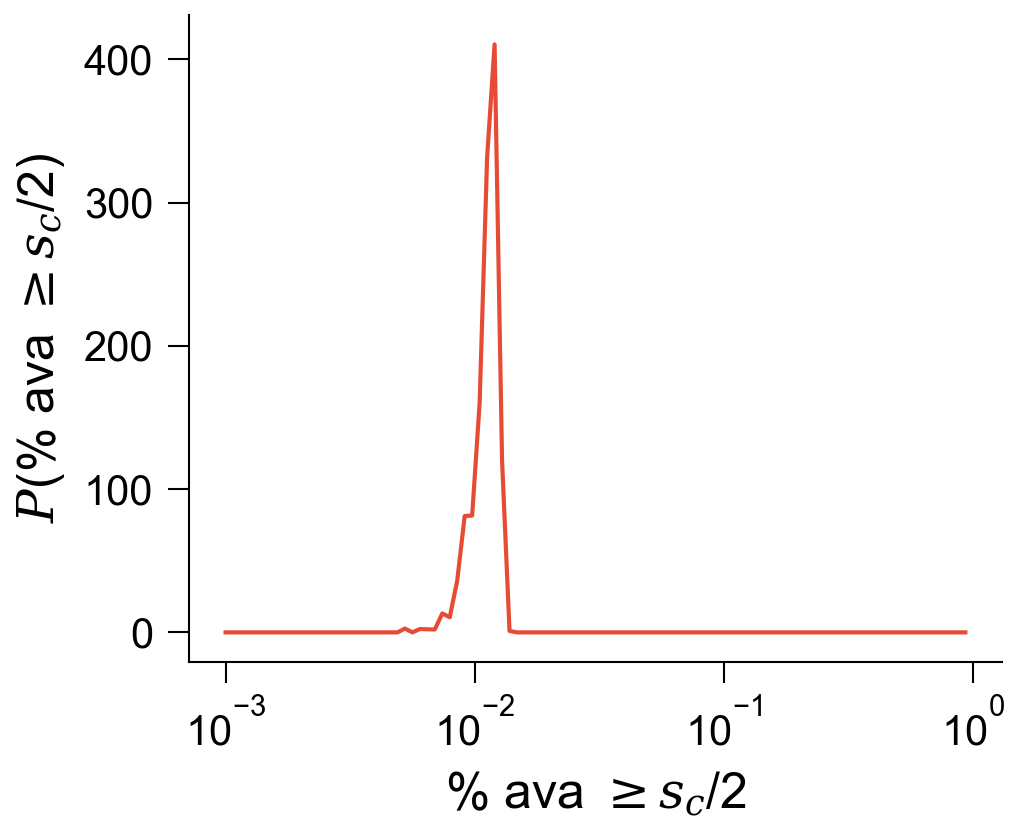

In [212]:
data = np.loadtxt("{}/random_histo_si.txt".format(folder))

nbins = 100
bins_C = np.logspace(np.log10(1), np.log10(L1 * L2), nbins +1)
bins_center_C = (bins_C[1:]+bins_C[:-1])/2

frac = 2
nb_size_nbtot = np.zeros(1000)  #nb sc trouver avec une taille proche s_c/ nbtry total 

sum_data = np.sum(data, axis = 0)
for i, line in enumerate(data):
    
    max_id = np.where(line !=0)[0][-1]
    max_size = bins_center[max_id]
    mask = bins_center >= max_size/frac
    
    nb_size_nbtot[i] = np.sum(mask)

nb_size_nbtot /= (L1*L2)//10    
       
bins_nb_size_nbtot = np.logspace(np.log10(0.001), np.log10(1), nbins +1)
# bins_nb_size_nbtot = np.linspace(0.001, 1, nbins +1)
        
histo_nb_size_nbtot, _ = np.histogram(nb_size_nbtot, bins = bins_nb_size_nbtot, density = True)

with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    ax.plot(bins_nb_size_nbtot[:-1], histo_nb_size_nbtot)
    
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel(r'% ava $\geq s_c$/{}'.format(frac))
    ax.set_ylabel(r'$P$(% ava $\geq s_c$/{})'.format(frac))
    plt.show()
        
        
        

## On regarde la position de l'épicentre réel de l'épicentre donnant la plus grande avalanche

In [4]:



Nava = np.zeros(1000)
nin = np.zeros(1000)
s = np.zeros(1000)
new_nin = np.zeros(1000)
new_s = np.zeros(1000)
nbtry = np.zeros(1000)

sc_patch = np.zeros(1000)
nbtry_nbtot = np.zeros(1000)
nb_size_nbtot = np.zeros(1000)
max_patch_size = np.zeros(1000)

with gzip.open("{}/random_random.gz".format(folder), "rt") as f:
    skip = f.readline()
    # print(skip)
    for i, line in enumerate(f):
        if i == 0:
            print(line)
        col = line.split()
        Nava[i]= int(col[0])
        nin[i] = int(col[3])
        s[i] = int(col[4])
        new_nin[i] = int(col[6])
        new_s[i] = int(col[7])
        nbtry[i] = int(col[5])
        patch_size = np.array(col[9:], dtype = int)
        max_patch_size[i] = np.max(patch_size)

        sc_patch[i] = new_s[i]/max_patch_size[i]
        nbtry_nbtot[i] = nbtry[i]/nbmaxtry
        
print(np.argmax(max_patch_size))
print(Nava[385])

        

786286  2.08996  6.40389e+07  57830  1  12  14843  416  1.67943  2 9 6 2 25 108 218 183 36 66 56 12 107 1581 35 39 42 202 21 127 8 613 2 34 21 914 11 16 46 28 2 51 389 8 29 14 8 12 9 2 127 79 2 679 21 142 17 419 89 183 47 1 2 54 144 4 1189 53 11 11 27 89 118 44 1 16 875 335 99 503 9 232 28 40 58 30 12 27 18 10 7 5 2 3 2 72 65 4 6 678 4 161 88 79 5 6 17375 252 47 3 14 8 2 2 5 1148 2 10 1 1 6 1 1 5 1 34 32 18 8 4 17 4 6 6 137 2 52 16 1 22 80 8 20 22 6 1 3355 280 30 111 1 4 4 383 1836 60 1 855 21 8 1 168 66 12 285 28 127 8 283 90 137 1 2 43 4 792 3 259 4897 1 39 9 2302 43 4 8 40 94 47 13 1 170 65 5 47 116 43 5 769 66 10 51 3 108 32 9 8 12 4 48 1070 318 11050 4 2 85 224 18 20 500 184 612 75 23 6 87 159 1 79 12 49 21 10 36 35 59 10 24 24 18 11 11 5 3 3 

385
332314599.0


In [214]:
print(nbtry_nbtot)

[1.83094294e-03 6.04668904e-01 6.40982606e-01 9.00213610e-01
 4.95880378e-02 1.37015563e-01 1.83094294e-02 6.69362222e-01
 8.69392737e-01 3.15837656e-01 2.92493134e-01 4.83521514e-01
 2.15746109e-01 5.61794324e-01 1.77906622e-01 4.59108941e-01
 2.36954532e-01 2.29020446e-01 1.76991150e-01 3.22856271e-01
 5.35245652e-01 1.76991150e-01 4.99084529e-01 2.25205981e-01
 7.13304852e-01 1.39914556e-01 6.55019835e-01 8.96551724e-01
 3.03631370e-01 5.67592310e-01 7.25663717e-01 3.00884956e-01
 4.25694233e-02 5.64540738e-02 4.81995728e-01 2.39548367e-02
 9.67043027e-01 2.96002441e-02 8.90753738e-01 4.94354593e-01
 2.64418676e-01 2.09795545e-01 6.66768386e-02 3.24534635e-01
 1.47085749e-01 3.20415014e-03 8.43759536e-02 1.24656698e-01
 1.57003357e-01 2.93103448e-01 5.18004272e-01 6.11534940e-01
 1.18553555e-01 3.53982301e-01 6.32743363e-01 6.97894416e-01
 2.67927983e-01 1.14739091e-01 1.03295697e-01 4.62313091e-01
 2.42447360e-01 3.86023802e-02 1.16570034e-01 6.58376564e-01
 3.37351236e-01 7.363442

In [5]:

histo_sc_patch, bins_sc_patch = np.histogram(sc_patch, bins = np.logspace(np.log10(0.0001), np.log10(1), num=25), density= True)    #Sc/Taille max patch
histo_nbtry_nbtot, bins_nbtry_nbtot = np.histogram(nbtry_nbtot, bins = np.logspace(np.log10(0.0001), np.log10(1), num=25), density= True)    # nbtry pour trouver la taille max / nbtry total 


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/thesis.mplstyle


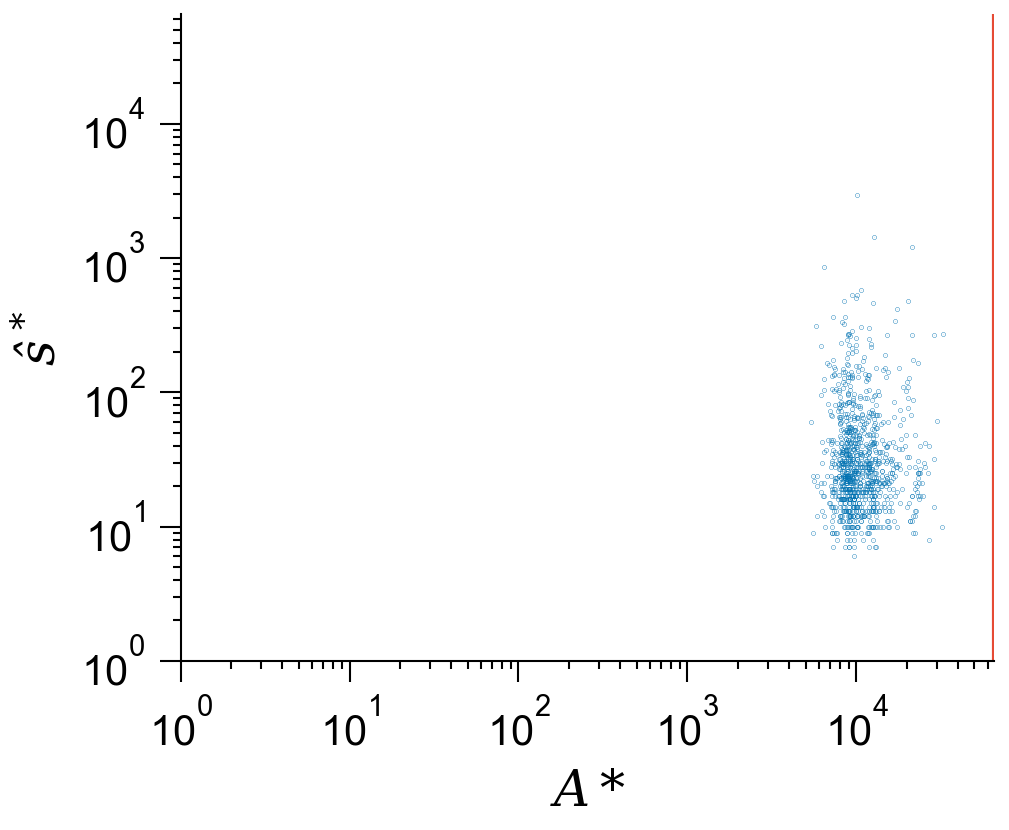

In [6]:
with plt.style.context(spstyle.get_style('thesis')):
    print(spstyle.get_style('thesis'))
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    ax.scatter(max_patch_size, new_s, s =0.01,  color = color_list[0])
    ax.axvline(65536)
    ax.set_xlim(1,65536)
    ax.set_ylim(1,65536)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel(r'$ŝ^*$')
    ax.set_xlabel(r'$A*$')

    plt.show()

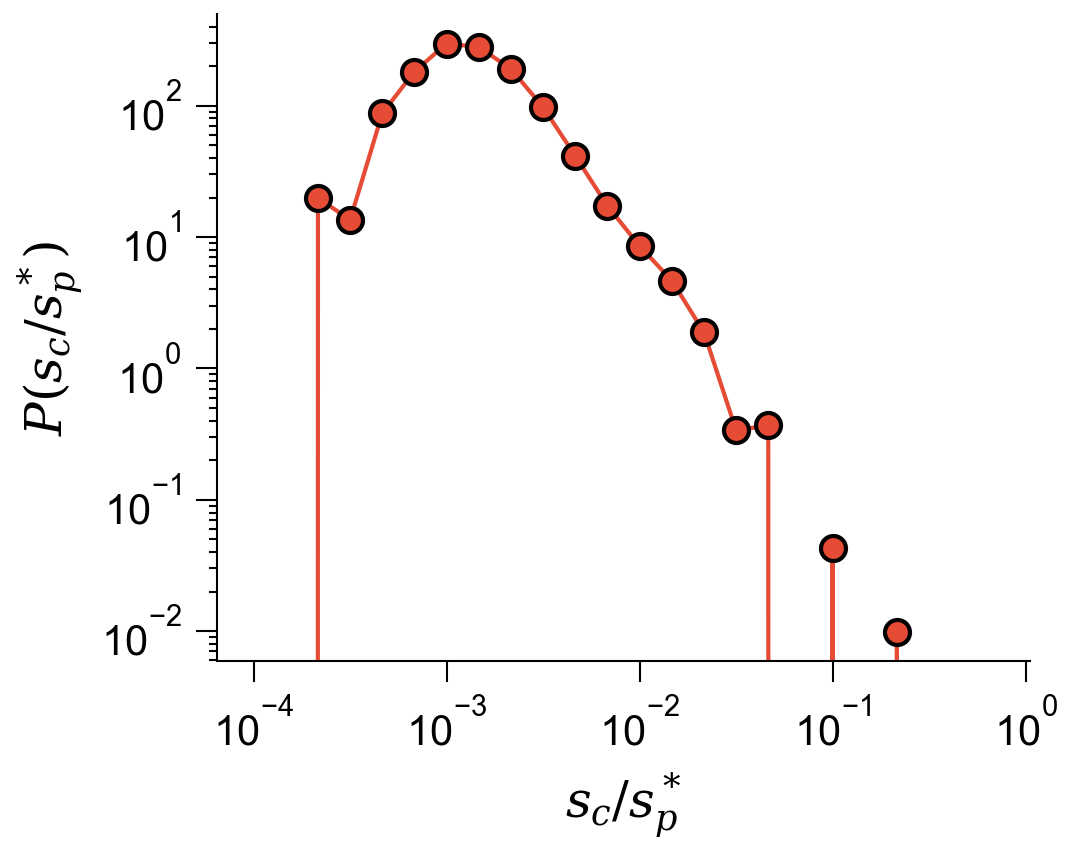

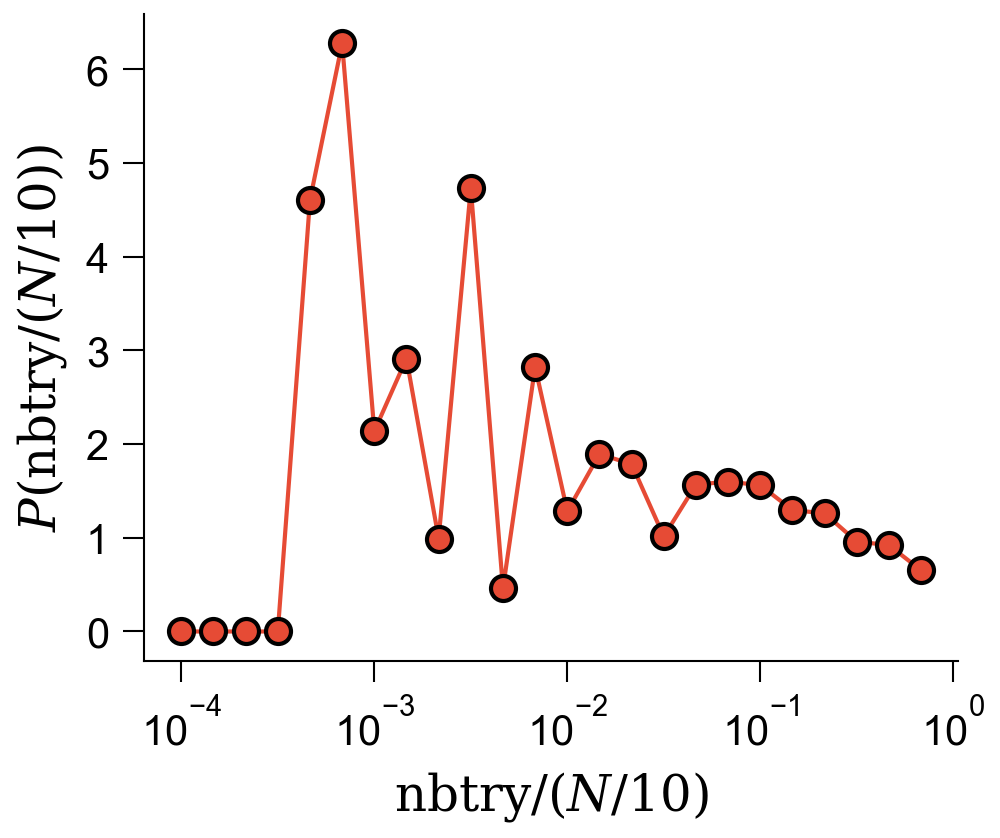

In [217]:
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    ax.plot(bins_sc_patch[:-1], histo_sc_patch, marker = 'o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s_c/s^*_p$')
    ax.set_ylabel(r'$P(s_c/s^*_p)$')
    plt.show()
    
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    ax.plot(bins_nbtry_nbtot[:-1], histo_nbtry_nbtot,  marker = 'o')
    ax.set_xlabel(r'$\mathrm{nbtry}/(N/10)$')
    ax.set_ylabel(r'$P(\mathrm{nbtry}/(N/10))$')
    ax.set_xscale('log')
    # ax.set_yscale('log')
    plt.show()
    

1.0 28.0
1.0 24.0
1.0 24.0
1.0 28.0
1.0 11.0
1.0 2958.0
1.0 12.0
1.0 11.0
1.0 29.0


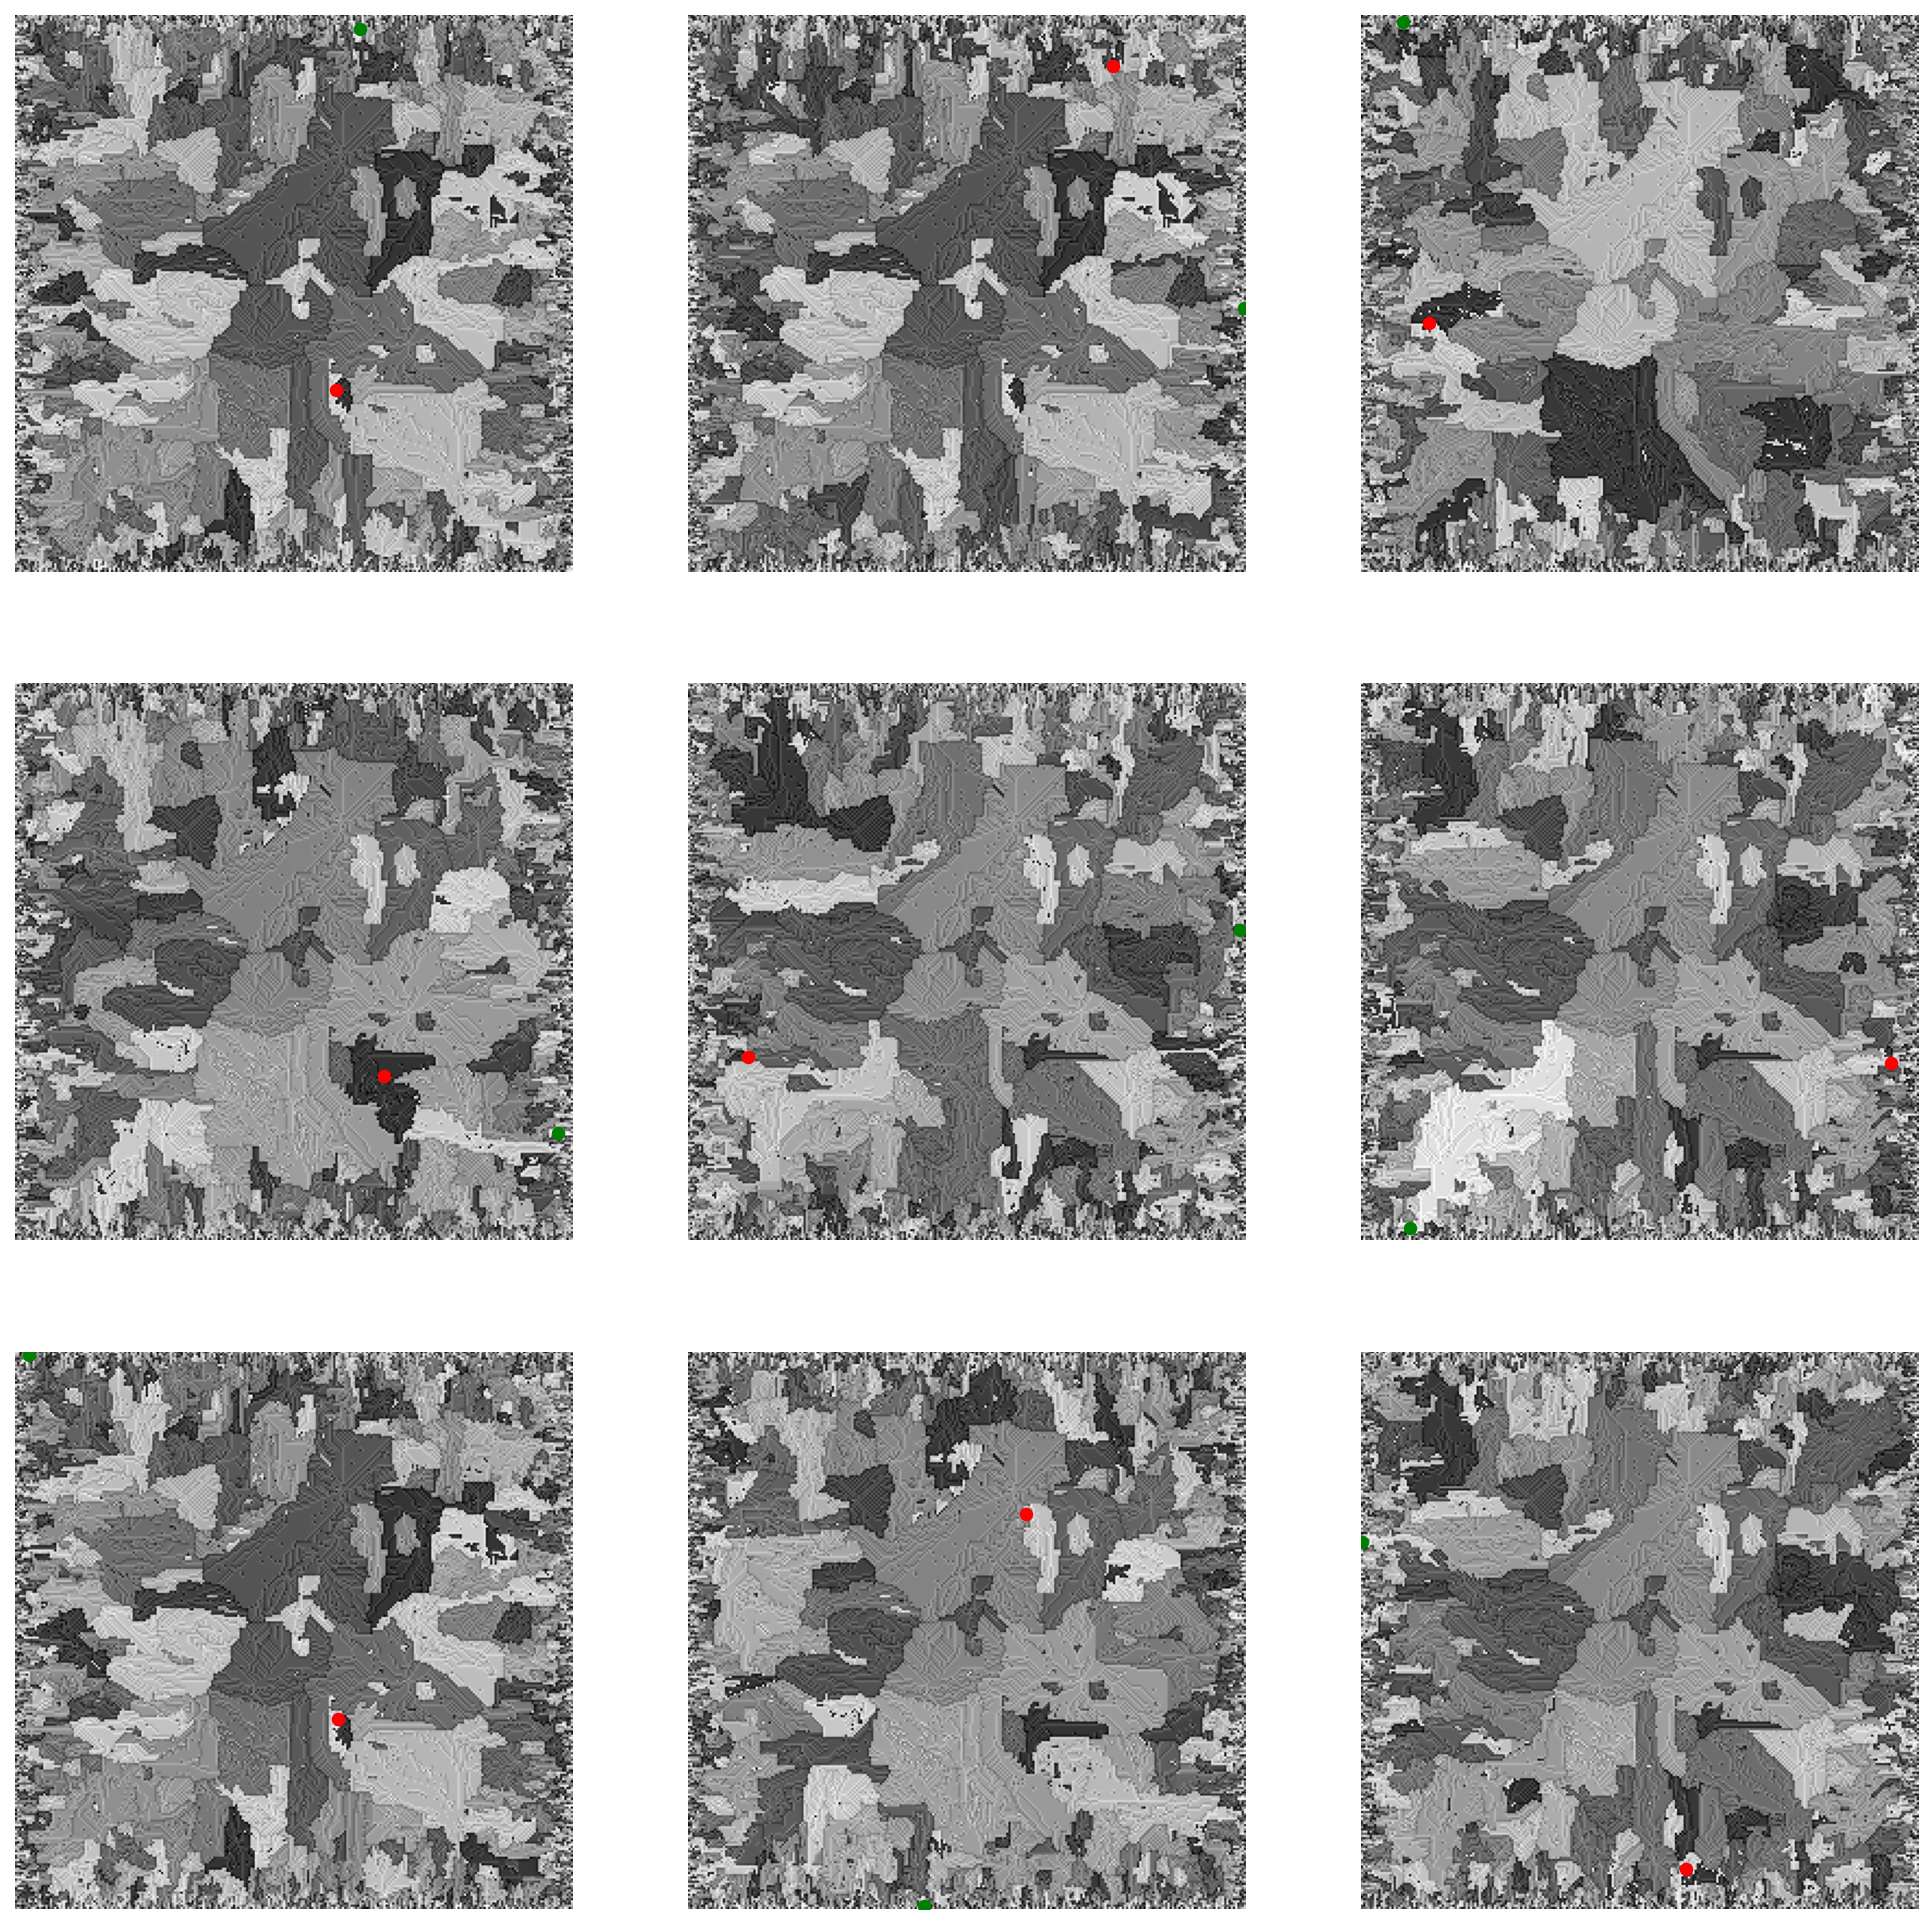

In [218]:
nbsnap = 10
id = np.random.randint(1000, size = 9)

with plt.style.context(spstyle.get_style('thesis')):
    fig, axis = plt.subplots(3,3, figsize = (8.2,8.2))

    axis = axis.flatten()
    for j, i in enumerate(id):
        file = "{}/Snapshots/nav{}_outputB.txt".format(folder, int(Nava[i]))
        snap = np.loadtxt(file,  comments='#').reshape(L1, L2)
        axis[j].imshow(snap, cmap = 'binary')
        nin_y, nin_x = np.unravel_index(int(nin[i]), (L1, L2))
        sc_nin_y, sc_nin_x = np.unravel_index(int(new_nin[i]), (L1, L2))
        axis[j].scatter(nin_x, nin_y, color = 'r', s = 5)
        axis[j].scatter(sc_nin_x, sc_nin_y, color = 'g', s = 5)
        axis[j].set_axis_off()
        
        print(s[i], new_s[i])
        
    plt.show()
        
    
    
    

#   P_top*

In [3]:
Tfolder_nb = [1,2,3,4]
path = "/data1/DATA_Duplat/Brut/Largest_ava_toppling_distrib/La"
Tbin_ntop1, Thisto_ntop1, Tbin_ntopa1, Thisto_ntopa1 = full_analysis(Tfolder_nb, path = path, nbfolder = np.arange(1,10), nbins = 50, cols =[9])

19000
200000
230000
150000


In [4]:
Tfolder_nb = [77,78,79,80,81,83, 82]
Tbin_s1, Thisto_s1, Tbin_a1, Thisto_a1 = full_analysis(Tfolder_nb, nbfolder = [2,3,4,5,6,7,8,9], nbins = 50, cols =[12])

36000
360000
390000
380000
360000
290000
340000


In [5]:
Tnu_th, Tgamma_th, Ttau_s_th = gamma_th()

0.96545763582405
0.9971726928826957
0.9940950079772213
0.9970879131270517
0.9967105205796035
0.9906659255469019
0.9877020531728582
0.9272213838997168
0.9122521887346848
0.9705872766834267
0.9174095398449836
0.9057453446744788
0.8991641398725068
0.8933054895985362


/tmp/ipykernel_1338704/3075213186.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_1338704/3075213186.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor_ntop = [plt.cm.get_cmap('inferno')(i/len(Tnu_ntop)) for i in range(len(Tnu_ntop))]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/thesis.mplstyle


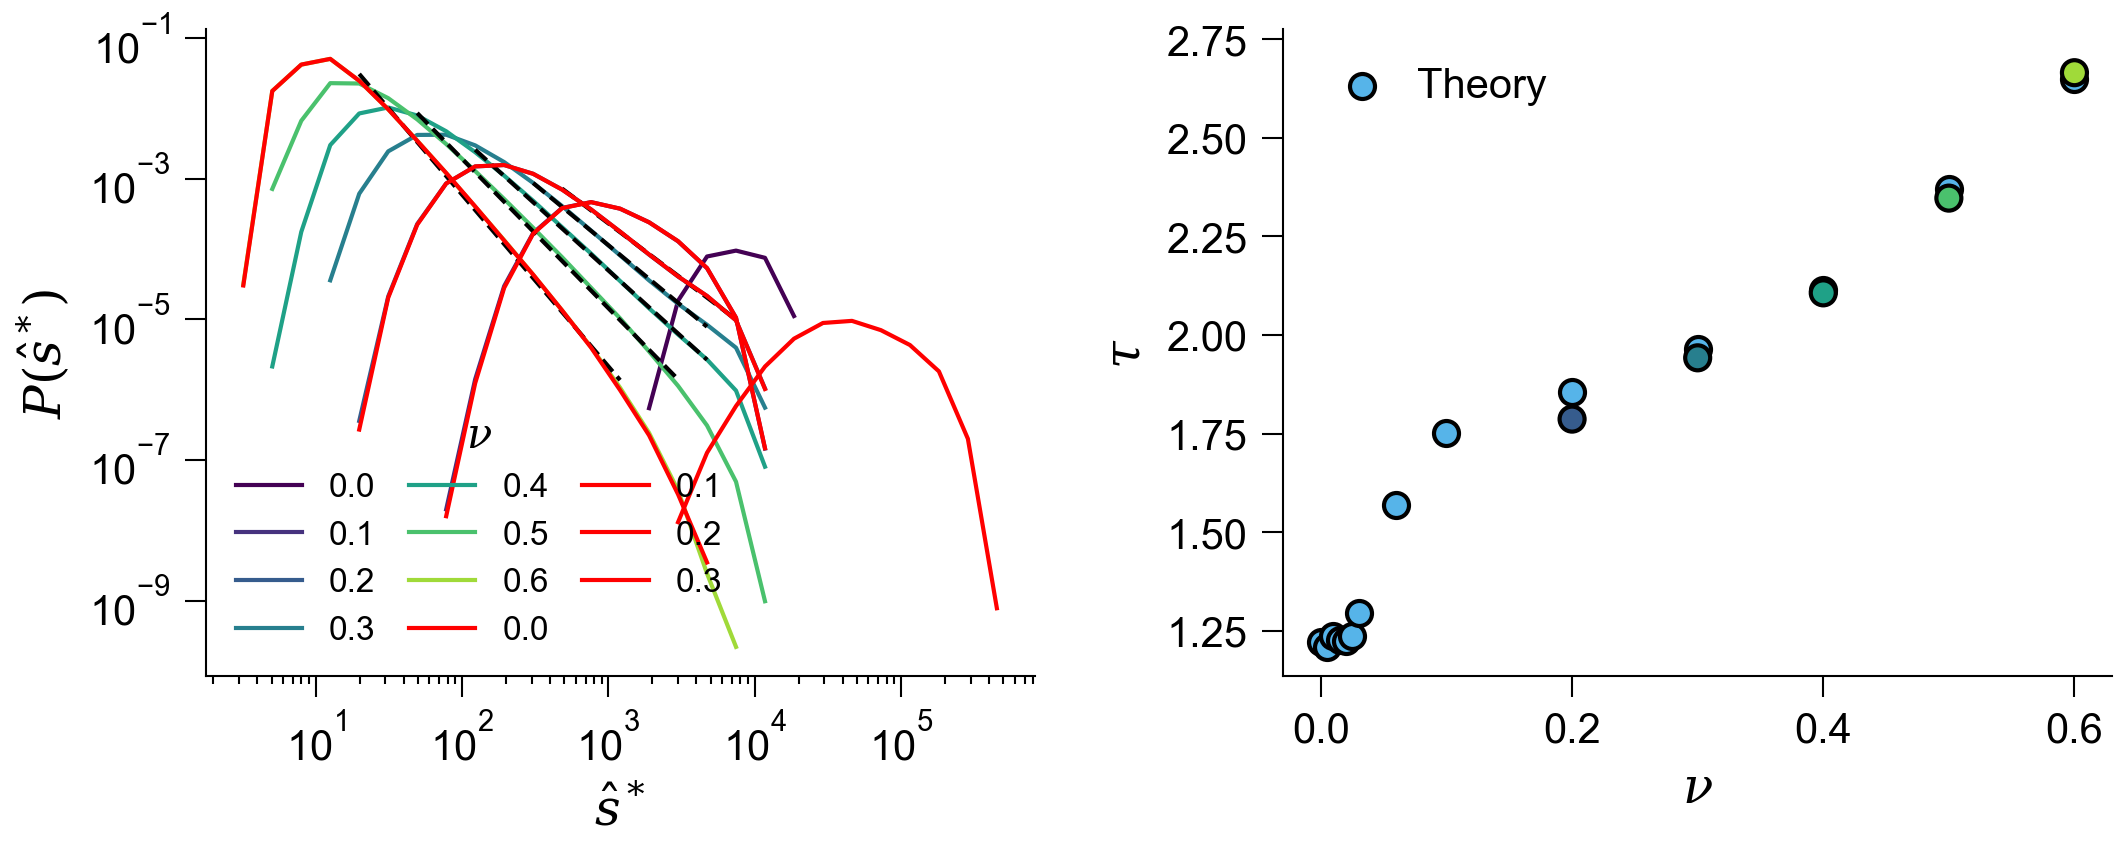

In [6]:
import warnings
from matplotlib.ticker import FixedLocator, NullLocator
from mpl_toolkits.axisartist.axislines import SubplotZero

warnings.resetwarnings()

Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tnu_ntop = [0.0, 0.1, 0.2, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 6e3, 1.2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 1e3, 400, 200, 100, 40, 15]
Tphi = [None]*len(Tnu)
Tperr = [None]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

Tcolor_ntop = [plt.cm.get_cmap('inferno')(i/len(Tnu_ntop)) for i in range(len(Tnu_ntop))]

max_nbtry = 6554

warnings.filterwarnings("error")
with plt.style.context(spstyle.get_style('thesis')):
    print(spstyle.get_style('thesis'))

    fig, (ax2,ax1) = plt.subplots(1,2,figsize=(8.2, 2.8))
    fig.subplots_adjust(wspace = 0.3)
    
    
    ######P(smax)######
    for j, n in enumerate(Tnu):
        ax2.plot(Tbin_s1[j], Thisto_s1[j], c = Tcolor[j], label = f"{Tnu[j]}")
        if j not in [0, 1]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
            Tperr[j] = np.sqrt(np.diag(pcov))[1]
            Tphi[j] = popt[1]
            yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
            ax2.plot(Tbin_s1[j][start:stop], yfit, ls = '--', c ='k', lw =1)

    for j, n in enumerate(Tnu_ntop):
        ax2.plot(Tbin_ntop1[j], Thisto_ntop1[j], c = 'r', label = f"{Tnu[j]}")
    
    # ax1.scatter(Tnu_th, 2-(-Tgamma_th), c = color_list[2], label = r'Theory')
    # ax1.errorbar(Tnu[2:], -np.array(Tphi)[2:], yerr = Tperr[2:], c = 'k', ls = ' ')
    # ax1.scatter(Tnu[2:], -np.array(Tphi)[2:], c = Tcolor[2:], zorder = 2)
    
    ax1.scatter(Tnu_th, Ttau_s_th, c = color_list[2], label = r'Theory')
    ax1.errorbar(Tnu[2:], -np.array(Tphi)[2:]+Ttau_s_th[0]-1, yerr = Tperr[2:], c = 'k', ls = ' ')
    ax1.scatter(Tnu[2:], -np.array(Tphi)[2:]+Ttau_s_th[0]-1, c = Tcolor[2:], zorder = 2)

    ax1.set_ylabel(r"$\tau$")
    ax1.set_xlabel(r"$\nu$")
    ax1.legend(fontsize = 10, handletextpad=0.3)
    
    ax2.set_xlabel(r"$\hat s^*$")
    ax2.set_ylabel(r"$P(\hat s^*)$")
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.legend(title = r"$\nu$", ncol = 3, columnspacing=1.0)


    
    fig.patch.set_alpha(0.0)

    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    # fig.savefig('Fig8.pdf', bbox_inches = 'tight', dpi = 600)
    plt.show() 
    
warnings.resetwarnings()